# Statistics for Michel electron candidate

### Created by Shu, 

##### (20250916) Main update here is the introduction of CLASS, to upgrade current cumbersome data processing

#### Dataset recording (2025 Official MC Production):



<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

# Part I: Very Initial Dataset
minus5GeV:    1k Files; MS > 1E-9

<br />

## Initial candidates:

In [12]:
from dataclasses import dataclass
import os

# ----------------------------- Dataclass ------------------------------------
@dataclass
class ParticleEvent:
    decayX_initial: float = None
    decayY_initial: float = None
    decayZ_initial: float = None
    startX_initial: float = None
    startY_initial: float = None
    startZ_initial: float = None
    MS_initial: float = None
    MH_initial: float = None
    energy_initial: float = None
    lifetime_initial: float = None
    pdg_initial: int = None
    eventID_initial: int = None
    trackID_initial: int = None


# ----------------------------- Helpers --------------------------------------
def read_values(file_path, cast_type=float):
    """Read a single file into a list."""
    values = []
    if not os.path.exists(file_path):
        print(f"[WARN] Missing file: {file_path}")
        return values
    with open(file_path, "r") as f:
        for line in f:
            val = line.strip()
            if val:
                try:
                    values.append(cast_type(val))
                except ValueError:
                    print(f"[WARN] Could not parse '{val}' in {file_path}")
    return values


def read_multiple(file_paths, cast_type=float):
    """Read multiple files and concatenate them."""
    combined = []
    for path in file_paths:
        combined.extend(read_values(path, cast_type))
    return combined


# ----------------------------- Configuration --------------------------------
data_groups = [
    {
        "data_dir": "./statResult_tpc",
        "dates": [
            "minus5GeV_1kFull"
        ]
    }
]

# map: class attribute -> (file prefix, value type)
fields_info = {
    "decayX_initial": ("decayX", float),
    "decayY_initial": ("decayY", float),
    "decayZ_initial": ("decayZ", float),
    "startX_initial": ("startX", float),
    "startY_initial": ("startY", float),
    "startZ_initial": ("startZ", float),
    "MS_initial": ("michelScore", float),
    "MH_initial": ("michelHits", float),
    "energy_initial": ("energy", float),
    "lifetime_initial": ("lifetime", float),
    "pdg_initial": ("pdg", int),
    "eventID_initial": ("eventID", int),
    "trackID_initial": ("trackID", int),
}

# ----------------------------- File Reading ---------------------------------
data = {k: [] for k in fields_info}  # initialize empty lists for each field

for group in data_groups:
    data_dir = group["data_dir"]
    dates_all = group["dates"]

    print(f"\n[INFO] Reading group: {data_dir}")
    for field, (stub, cast_type) in fields_info.items():

        for d in dates_all:
            file_path = f"{data_dir}/{stub}_{d}_initial.txt"
            vals = read_values(file_path, cast_type)

            data[field].extend(vals)
            print(f"  - Loaded {len(vals):6d} entries from {d} → appended to {field}")

print("\n[INFO] Combined totals:")
for field in data:
    print(f"  {field}: {len(data[field])} entries")


# ----------------------------- Build Events ---------------------------------
n_events = len(next(iter(data.values())))
events_reco = [
    ParticleEvent(**{k: data[k][i] for k in data})
    for i in range(n_events)
]

print(f"\n[OK] Created {len(events_reco)} ParticleEvent objects.")


print("Candidates ( MH > xxx): ", len(events_reco))

print("\nExample: ")
print(events_reco[0].decayX_initial)
print(events_reco[0].energy_initial)
print(events_reco[0].pdg_initial)




# ----------------------------- Create Lists for Direct Access ----------------
# Create standalone lists (just like your old style)
decayX_initial   = data["decayX_initial"]
decayY_initial   = data["decayY_initial"]
decayZ_initial   = data["decayZ_initial"]
startX_initial   = data["startX_initial"]
startY_initial   = data["startY_initial"]
startZ_initial   = data["startZ_initial"]
MS_initial       = data["MS_initial"]
MH_initial       = data["MH_initial"]
energy_initial   = data["energy_initial"]
lifetime_initial = data["lifetime_initial"]
pdg_initial      = data["pdg_initial"]
eventID_initial  = data["eventID_initial"]
trackID_initial  = data["trackID_initial"]





#True Michel events----------
events_true = []
trueE_num = 0
trueL_num = 0
for ev in events_reco:
    if ev.energy_initial > 0:
        trueE_num += 1
        events_true.append(ev)
    if ev.lifetime_initial > 0:
        trueL_num += 1

print("\n# of True events: ", len(events_true))
print("Events with E > 0 (true Michel): ", trueE_num, "({:.2f}%)".format(trueE_num/len(events_reco)*100))
print("Events with L > 0 (true Michel): ", trueL_num, "({:.2f}%)".format(trueL_num/len(events_reco)*100))




[INFO] Reading group: ./statResult_tpc
  - Loaded  22299 entries from minus5GeV_1kFull → appended to decayX_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to decayY_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to decayZ_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to startX_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to startY_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to startZ_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to MS_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to MH_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to energy_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to lifetime_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to pdg_initial
  - Loaded  22299 entries from minus5GeV_1kFull → appended to eventID_initial
  - Loaded  22299 entries from minus5GeV_1kF


Decay points distribution: 
# of X < 0 :  11716 (52.54%)
# of X >= 0:  10583 (47.46%)


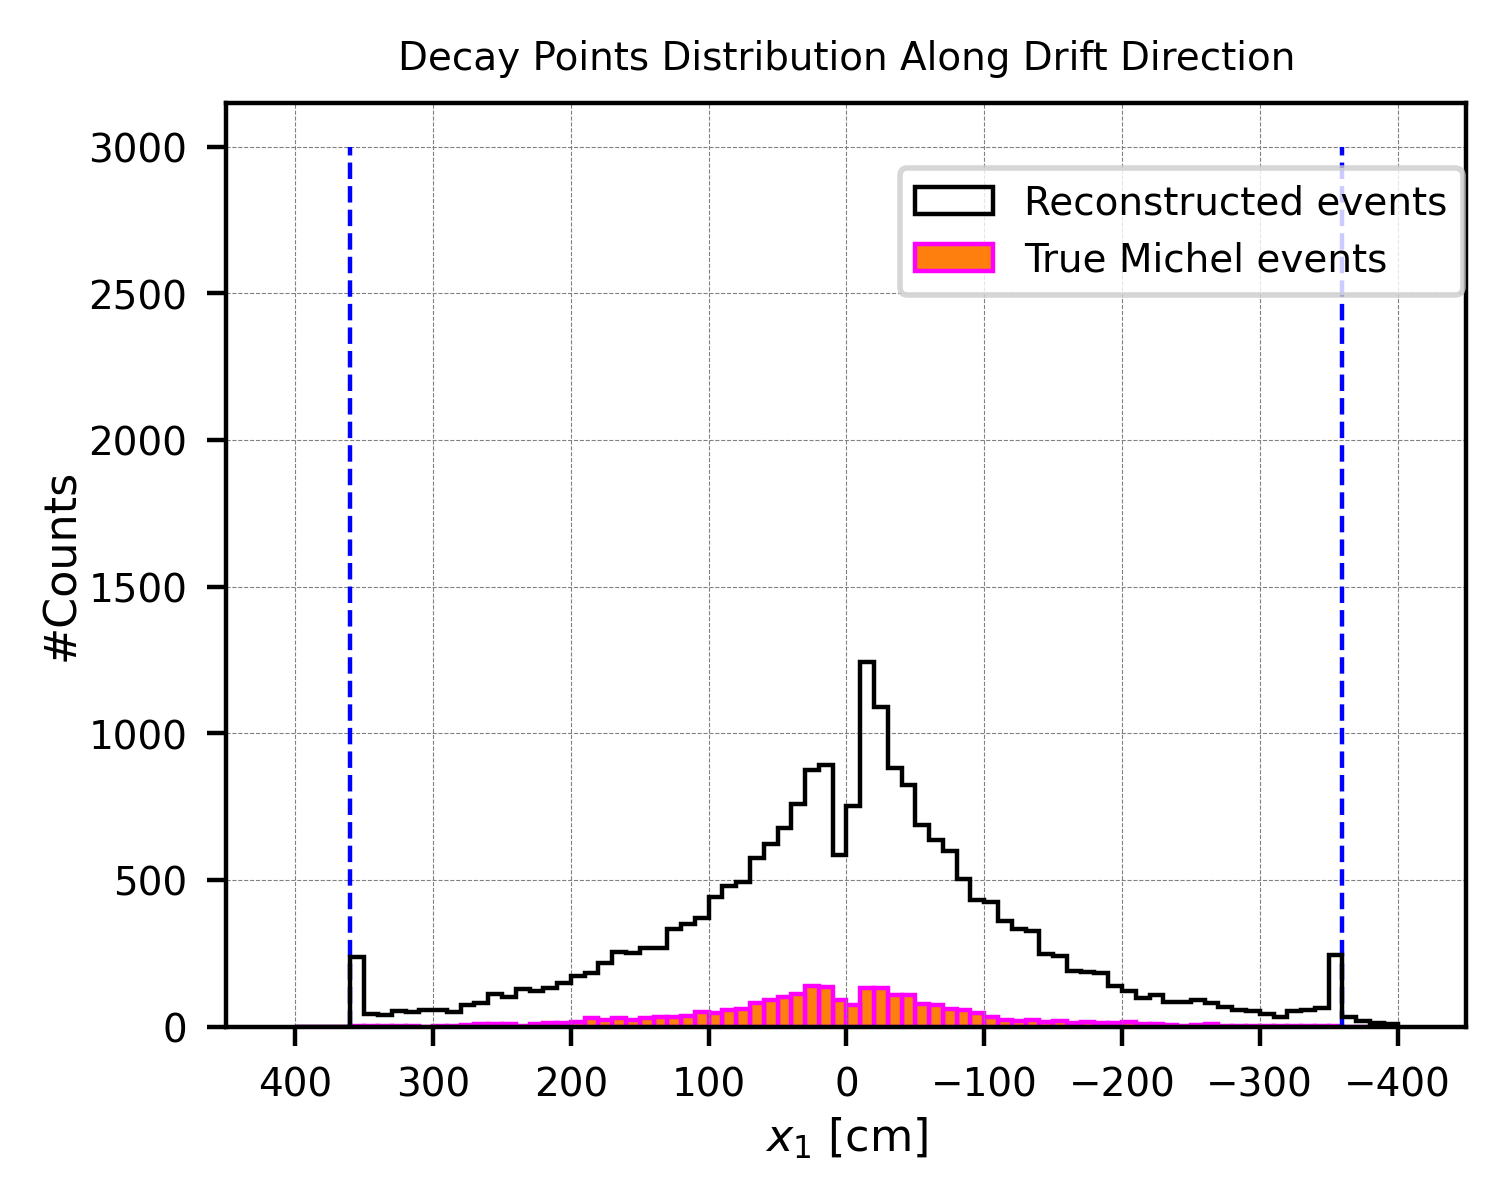

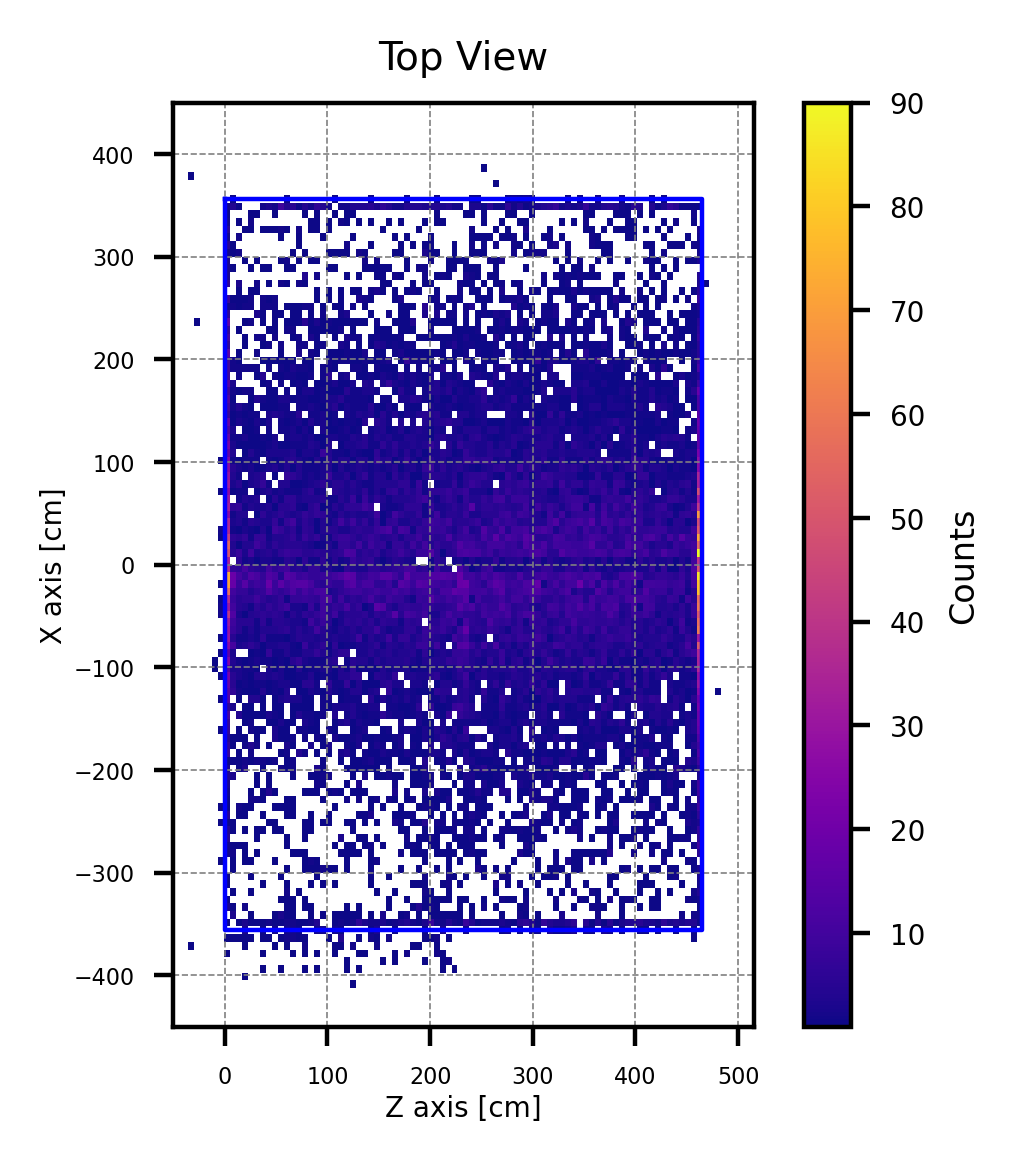

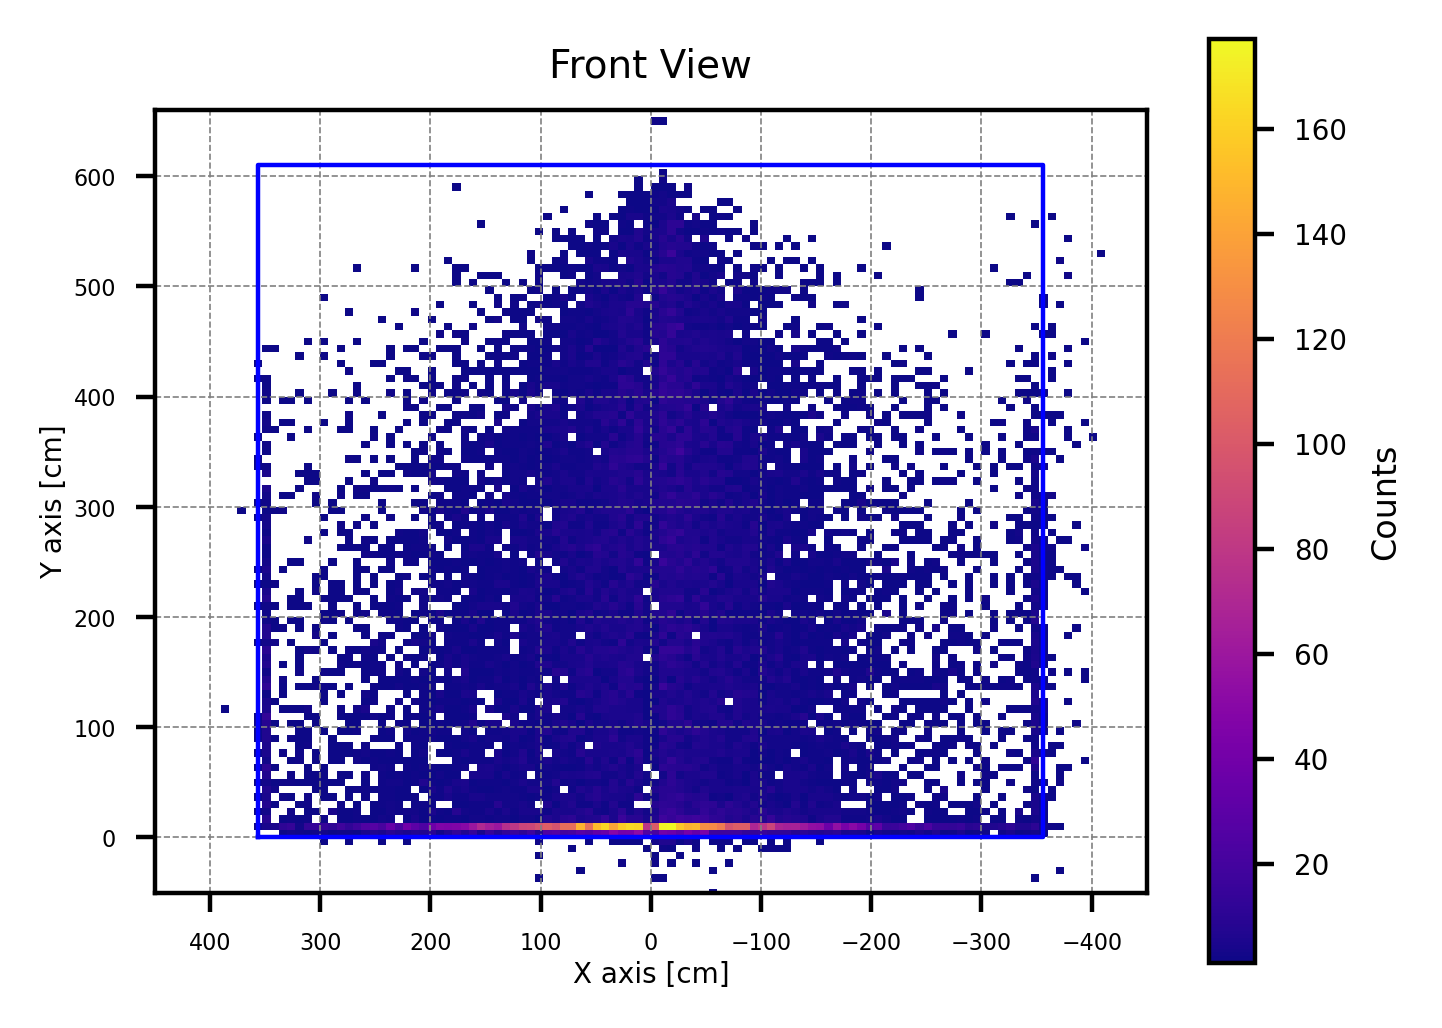

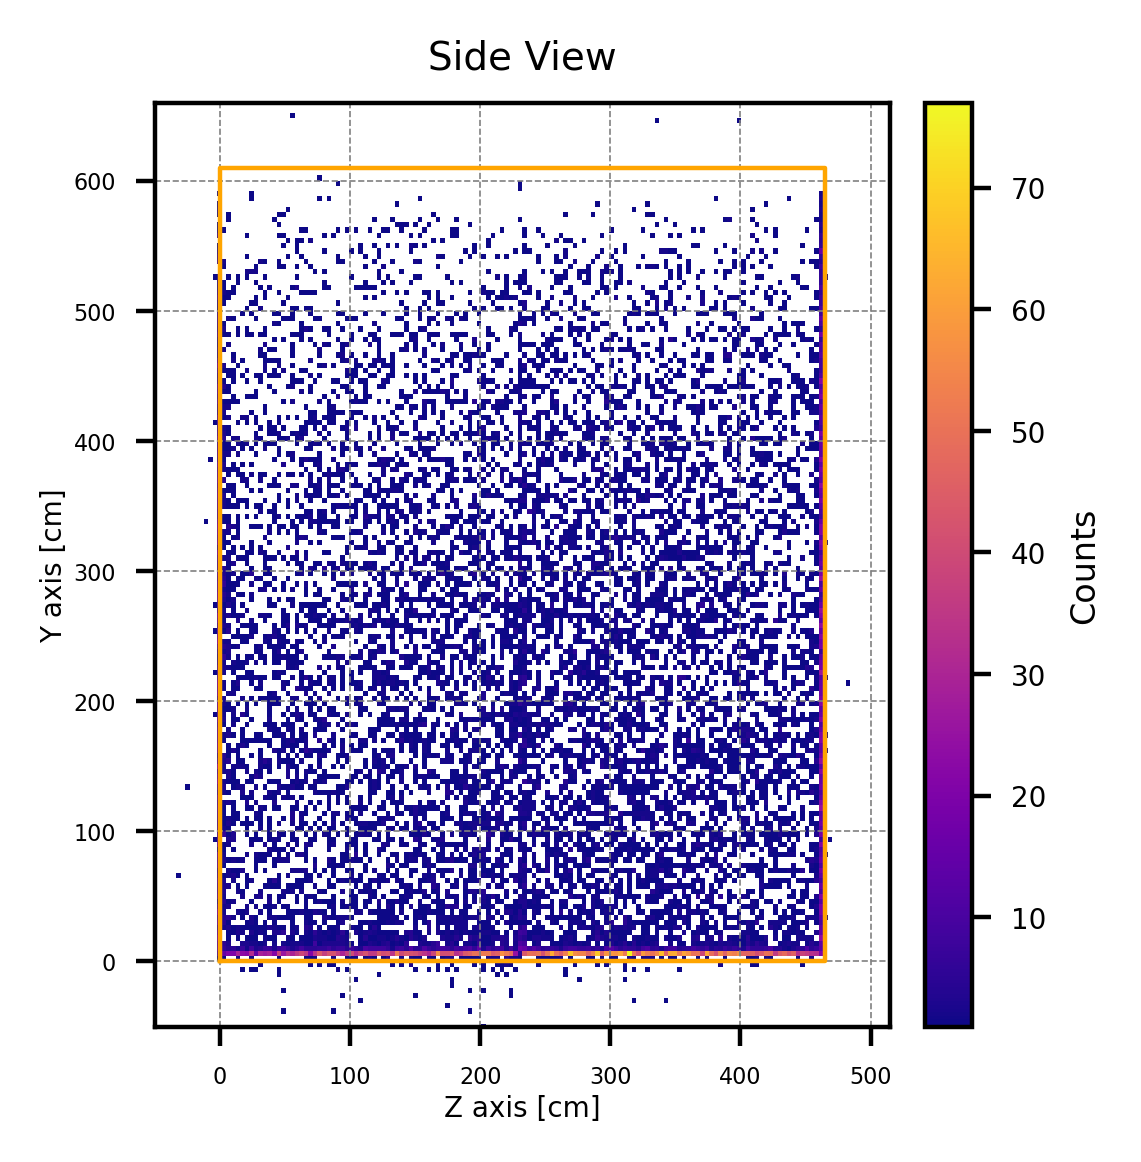


min(vals_MS_initial) 1.26385e-09
MS<0.01:  13461 / 22299 (60.37%)


<Figure size 1600x1200 with 0 Axes>

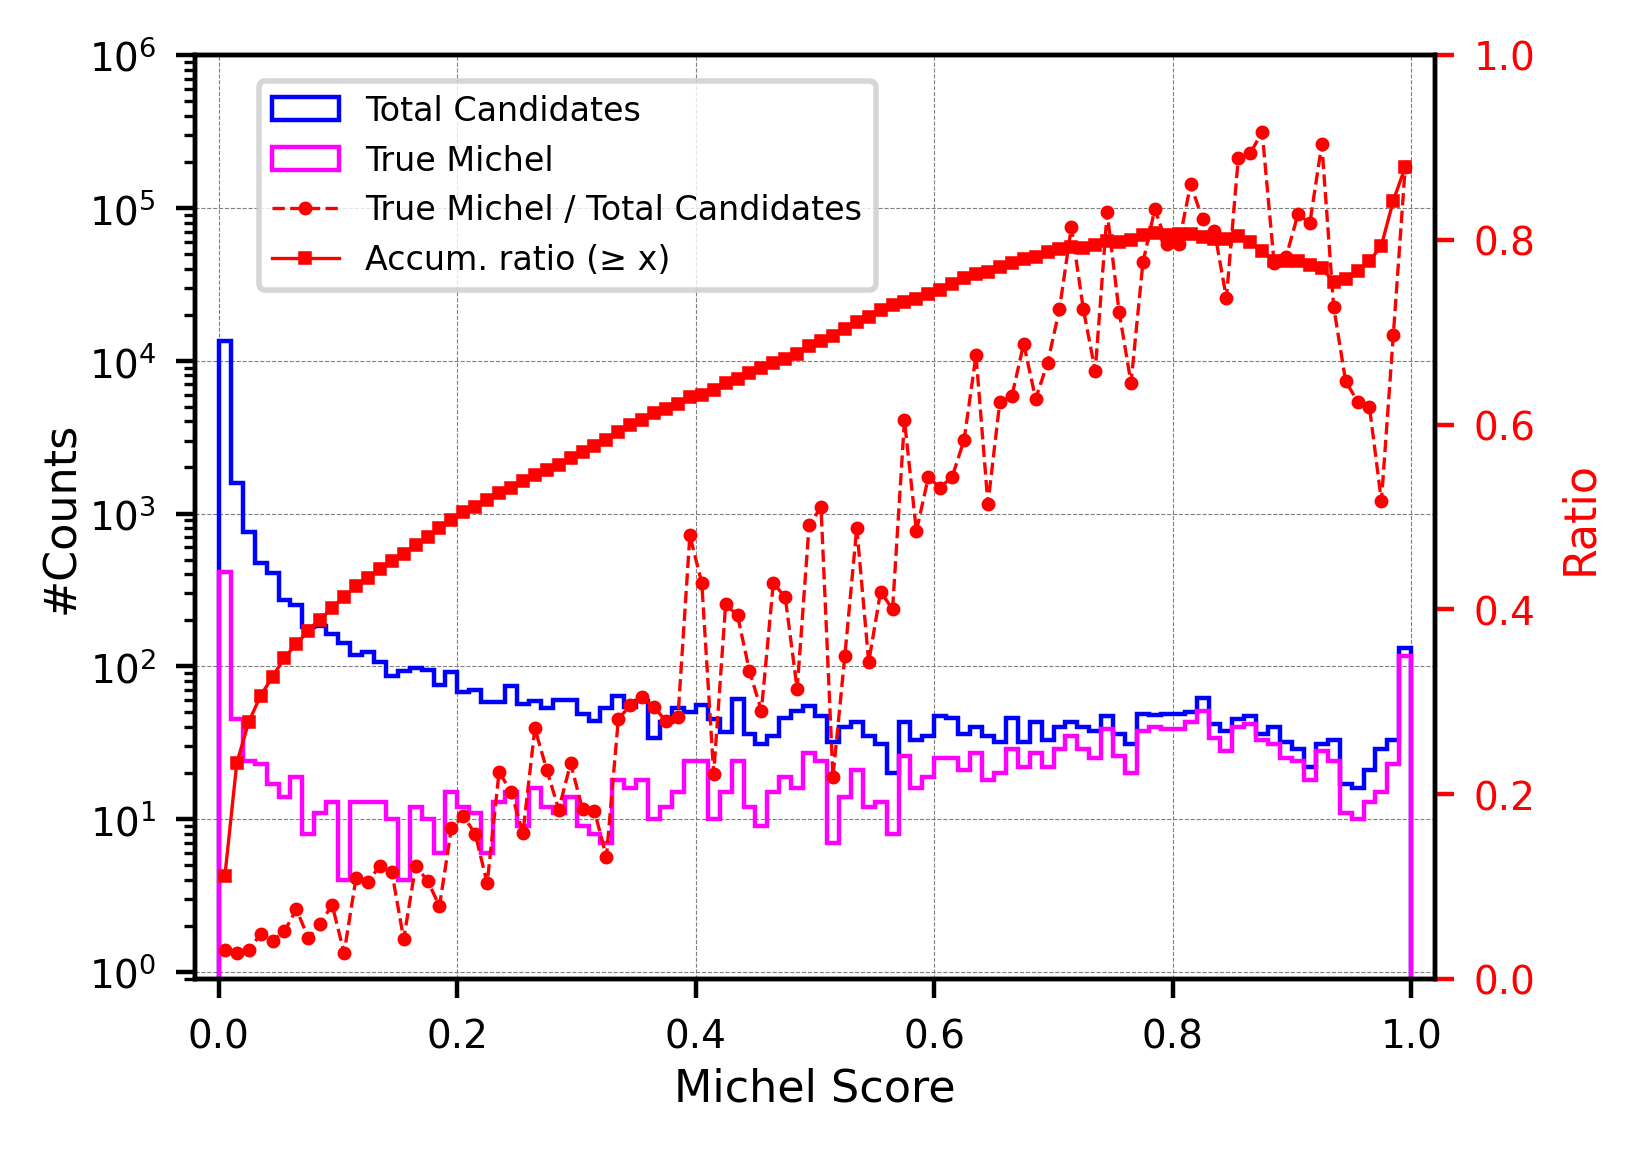

<Figure size 1600x1200 with 0 Axes>

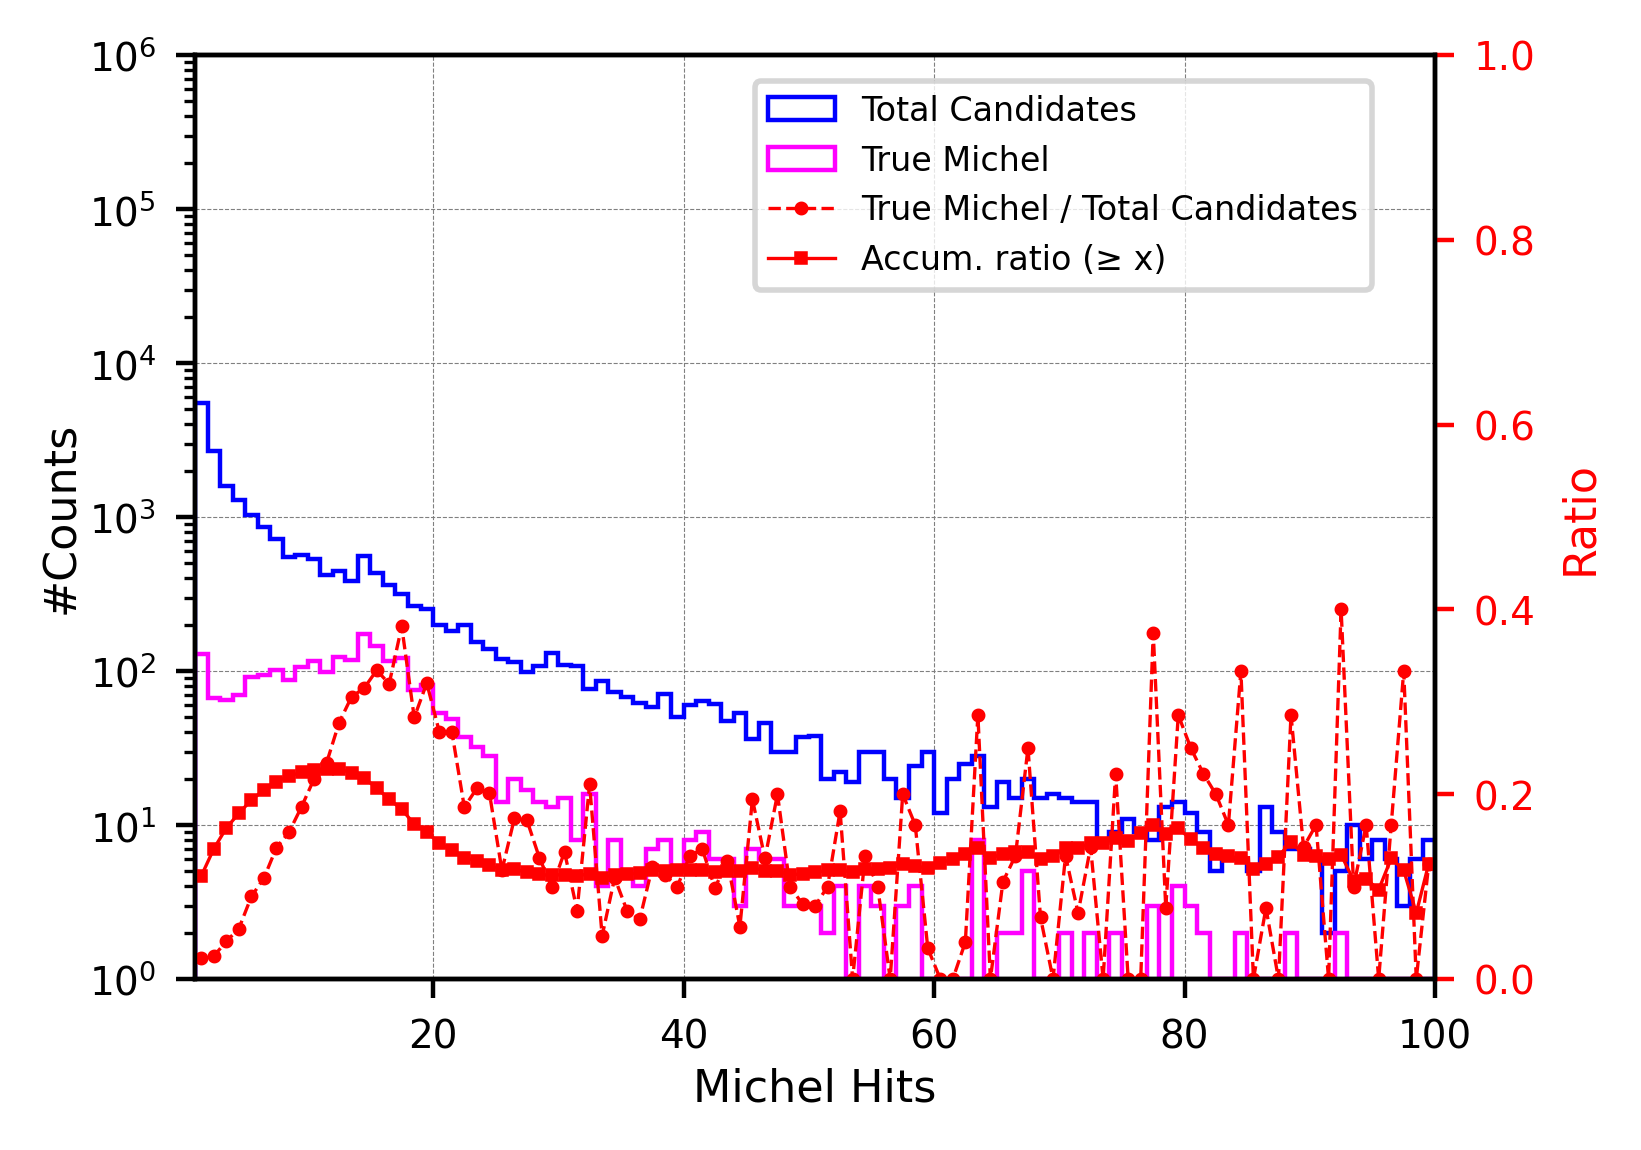

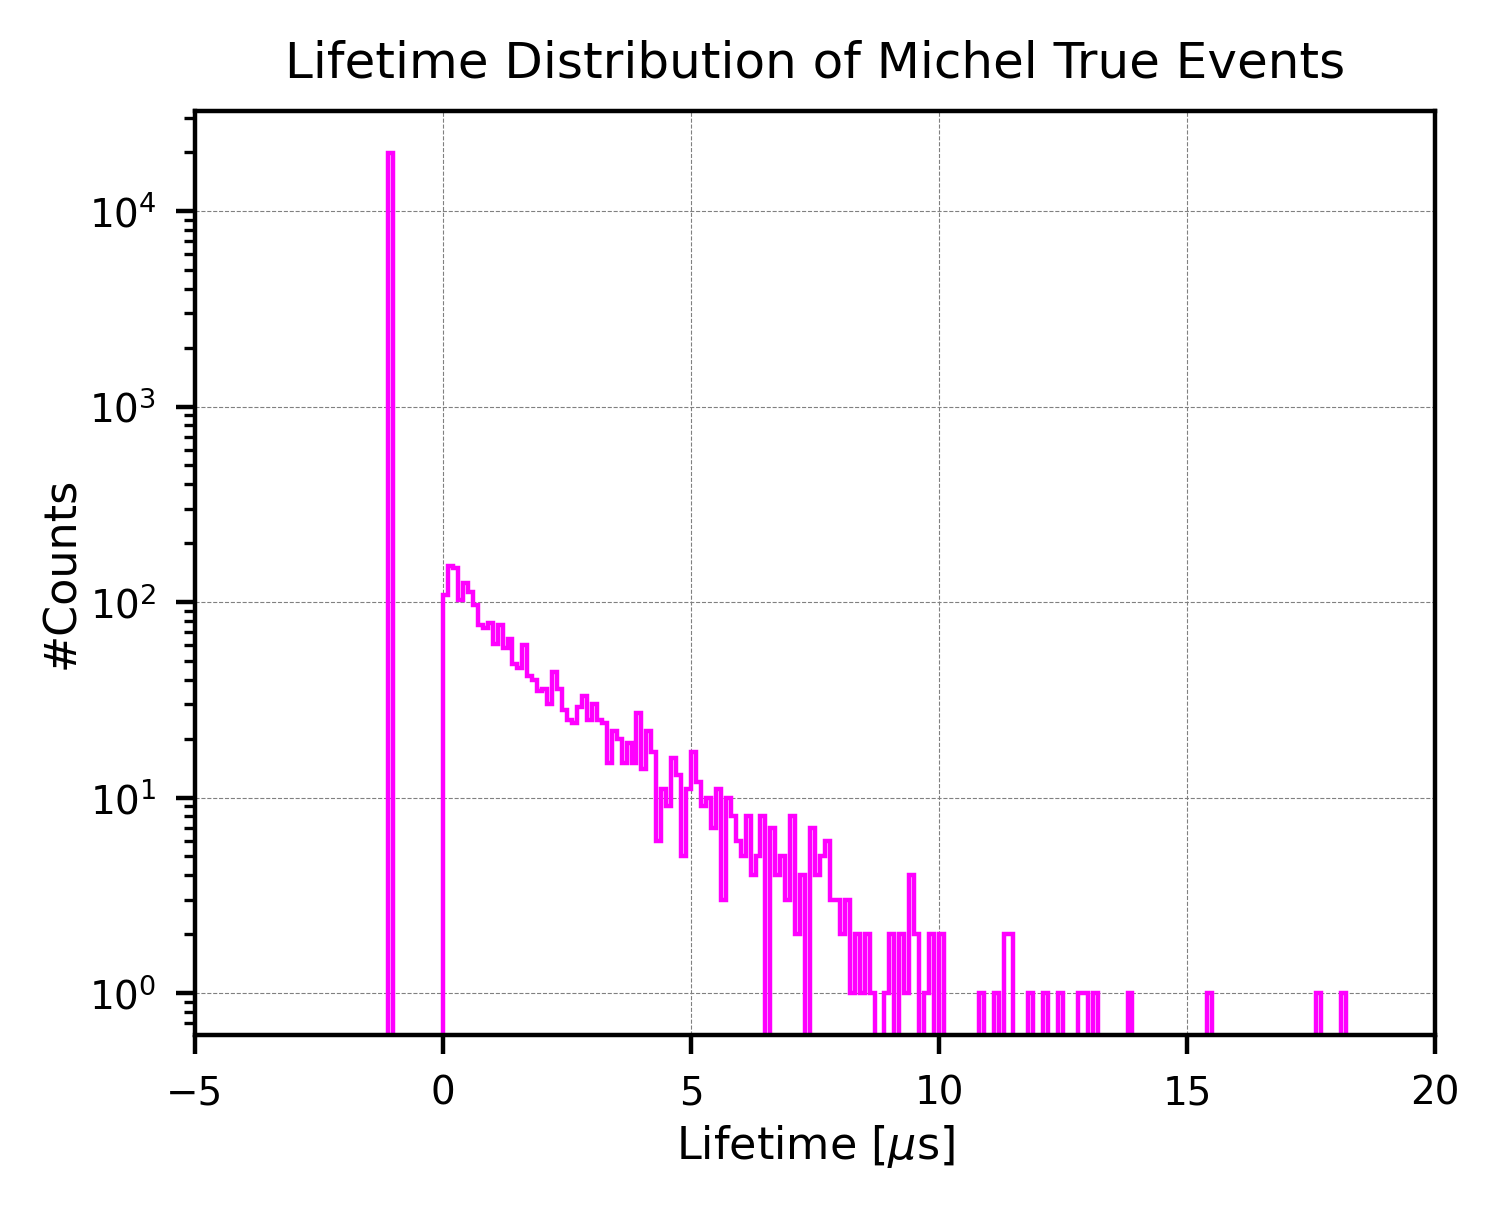

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in events_reco]
vals_decayY_initial = [ev.decayY_initial for ev in events_reco]
vals_decayZ_initial = [ev.decayZ_initial for ev in events_reco]
vals_MS_initial = [ev.MS_initial for ev in events_reco]
vals_MH_initial = [ev.MH_initial for ev in events_reco]
vals_lifetime_initial = [ev.lifetime_initial for ev in events_reco]

vals_decayX_true = [ev.decayX_initial for ev in events_true]
vals_MS_true = [ev.MS_initial for ev in events_true]
vals_MH_true = [ev.MH_initial for ev in events_true]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(vals_decayX_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 30000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(200, 200), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

print("\n==========================")
print("min(vals_MS_initial)", min(vals_MS_initial))
count = sum(1 for x in vals_MS_initial if x < 0.01)
print("MS<0.01: ", count, "/", len(vals_MS_initial),   "({:.2f}%)".format(count/len(vals_MS_initial)*100))



# Define the range and bin width
bin_width = 0.01
range_min = 0.0 #====================Remember to recover back---
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MS_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([0.5, 0.5], [0, 100000], color="green", linewidth=1.2, linestyle='--')

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02) #(-0.02, 1.02)
ax1.set_ylim(0.9, 1000000)
plt.yscale('log')
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")


# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0, 1.0)
ax2.tick_params(axis='y', labelsize=7, colors='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})


plt.show()








#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MH_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([8, 8], [0, 300000], color="green", linewidth=1.2, linestyle='--')


# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_ylim(1, 1000000)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
plt.yscale('log')
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ax2.set_ylim(0, 1.0)
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")



# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})

plt.show() 








#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_lifetime_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()









#### Preliminary Michel Score cut exploration:


min(vals_MS_initial) 1.26385e-09
MS<0.01:  13461 / 22299 (60.37%)
min(vals_MS_true) 3.5677e-09
MS<0.01:  417 / 2482 (16.80%)


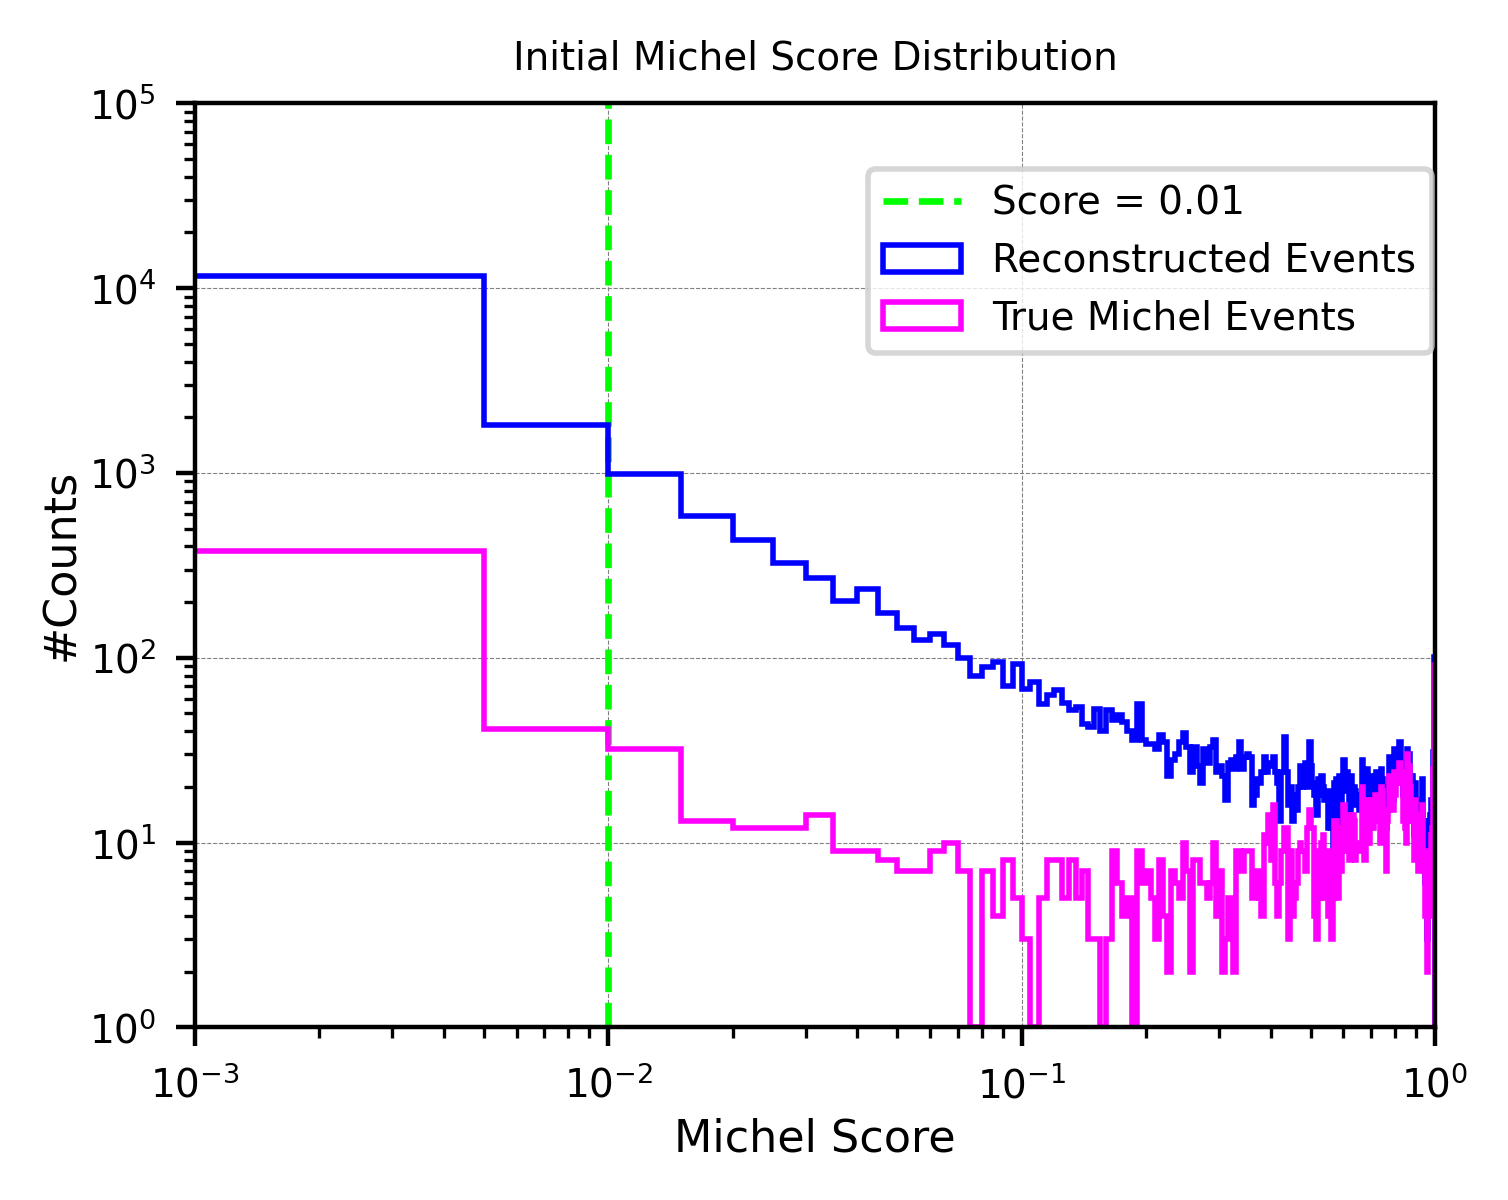

In [14]:
print("\n==========================")
print("min(vals_MS_initial)", min(vals_MS_initial))
count = sum(1 for x in vals_MS_initial if x < 0.01)
print("MS<0.01: ", count, "/", len(vals_MS_initial),   "({:.2f}%)".format(count/len(vals_MS_initial)*100))

print("min(vals_MS_true)", min(vals_MS_true))
count2 = sum(1 for x in vals_MS_true if x < 0.01)
print("MS<0.01: ", count2, "/", len(vals_MS_true),   "({:.2f}%)".format(count2/len(vals_MS_true)*100))





# Michel Score--------------------------------
plt.figure(figsize=(4,3),dpi=400)

#Define the range and bin width
bin_width = 0.005
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.plot([0.01, 0.01], [1, 100000], color="lime", linewidth=1.2, linestyle='--', label="Score = 0.01")

plt.hist(vals_MS_initial, bins=bins, range=(range_min, range_max), edgecolor='blue', 
         histtype='step', linewidth=1.0, label="Reconstructed Events")
plt.hist(vals_MS_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=1.0, label="True Michel Events")



plt.xlim(0.001, 1.0)
plt.xscale('log')
plt.xlabel('Michel Score', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(1, 100000)
plt.yscale('log')
plt.title('Initial Michel Score Distribution', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  

<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

## TPC cuts:


### Apply cuts gradually:

In [15]:

Space_events_reco = []
MS_events_reco = []
MH_events_reco = [] # After Space & MS & MH cuts---


Space_events_true = []
MS_events_true = []
MH_events_true  = [] # After Space & MS & MH cuts---




#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial



    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    
        Space_events_reco.append(ev)
        if E > 0:
            Space_events_true.append(ev)

        if MS > 0.2: #(Michel score cut)---
            MS_events_reco.append(ev)
            if E > 0:
                MS_events_true.append(ev)
            
            if MH > 2: #Michel hits cut---                
                MH_events_reco.append(ev)
                if E > 0:
                    MH_events_true.append(ev) 
                    
                    
                    

                    
#Initial size of dataset:-----
print("Reco events (initial): ", len(events_reco))
print("True events (initial): ", len(events_true), "({:.2f}%)".format(len(events_true)/len(events_reco)*100))

print("\nReco events (Space cut): ", len(Space_events_reco), "({:.2f}%)".format(len(Space_events_reco)/len(events_reco)*100))
print("True events (Space cut): ", len(Space_events_true), "({:.2f}%)".format(len(Space_events_true)/len(Space_events_reco)*100))

print("\nReco events (Space & MS cuts): ", len(MS_events_reco), "({:.2f}%)".format(len(MS_events_reco)/len(events_reco)*100))
print("True events (Space & MS cuts): ", len(MS_events_true), "({:.2f}%)".format(len(MS_events_true)/len(MS_events_reco)*100))


print("\nReco events (Space & MS & MH cuts): ", len(MH_events_reco), "({:.2f}%)".format(len(MH_events_reco)/len(events_reco)*100))
print("True events (Space & MS & MH cuts): ", len(MH_events_true), "({:.2f}%)".format(len(MH_events_true)/len(MH_events_reco)*100))








Reco events (initial):  22299
True events (initial):  2482 (11.13%)

Reco events (Space cut):  10047 (45.06%)
True events (Space cut):  2167 (21.57%)

Reco events (Space & MS cuts):  2181 (9.78%)
True events (Space & MS cuts):  1568 (71.89%)

Reco events (Space & MS & MH cuts):  2038 (9.14%)
True events (Space & MS & MH cuts):  1519 (74.53%)


<br />
<br />

### Explore MS & MH Cuts (after Space cut):


Signal events [reco]:  1717 / 10047 (17.09%)
Signal events [true, purity]:  1383 / 1717 (80.55%)

BKG events [reco]:  3044 / 10047 (30.30%)
BKG events [true, purity]:  115 / 3044 (3.78%)


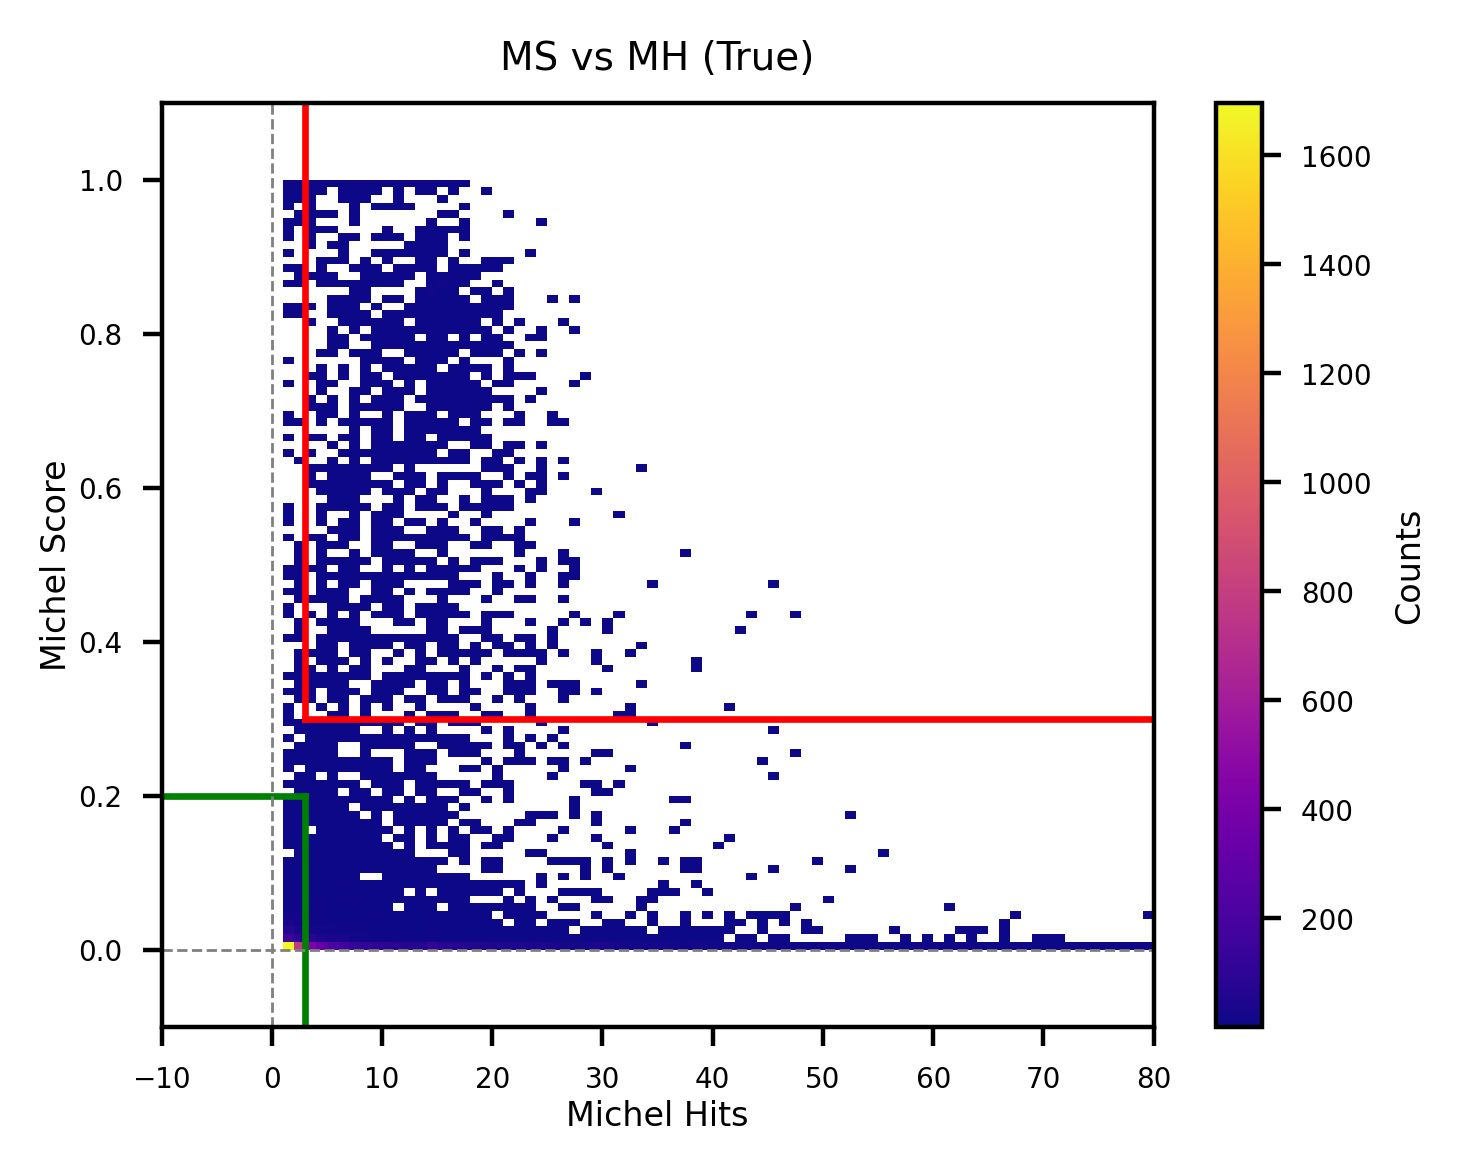

In [16]:

Space_events_reco = [] # After Space cuts---
Space_events_true  = [] # After Space cuts---

BKG_events_reco = []
BKG_events_true = []

Signal_events_reco = []
Signal_events_true = []


#Selection------
for ev in events_reco:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial
    MS = ev.MS_initial
    MH = ev.MH_initial

        
    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:       
        Space_events_reco.append(ev)
        if E > 0:
            Space_events_true.append(ev) 

        #Signal cut------
        if MS > 0.3 and MH > 3:
            Signal_events_reco.append(ev)
            if E > 0:
                Signal_events_true.append(ev)

        #BKG cut------
        if MS < 0.2 and MH < 3:
            BKG_events_reco.append(ev)
            if E > 0:
                BKG_events_true.append(ev)




print("\nSignal events [reco]: ", len(Signal_events_reco), "/", len(Space_events_reco),
      "({:.2f}%)".format(len(Signal_events_reco)/len(Space_events_reco)*100))
print("Signal events [true, purity]: ", len(Signal_events_true), "/", len(Signal_events_reco), 
      "({:.2f}%)".format(len(Signal_events_true)/len(Signal_events_reco)*100))


print("\nBKG events [reco]: ", len(BKG_events_reco), "/", len(Space_events_reco),
      "({:.2f}%)".format(len(BKG_events_reco)/len(Space_events_reco)*100))
print("BKG events [true, purity]: ", len(BKG_events_true), "/", len(BKG_events_reco), 
      "({:.2f}%)".format(len(BKG_events_true)/len(BKG_events_reco)*100))







vals_MS_Space = [ev.MS_initial for ev in Space_events_reco]
vals_MH_Space = [ev.MH_initial for ev in Space_events_reco]
#Michel Score vs Michel Hits==========================================================
plt.figure(figsize=(4,3),dpi=400)

# (x1, x2), (y1, y2)
plt.plot([3, 100], [0.3, 0.3], color="red", linewidth=1.2, linestyle='-')
plt.plot([3, 3], [0.3, 1.1], color="red", linewidth=1.2, linestyle='-')
plt.plot([-10, 3], [0.2, 0.2], color="green", linewidth=1.2, linestyle='-')
plt.plot([3, 3], [0.2, -0.1], color="green", linewidth=1.2, linestyle='-')

plt.plot([0, 0], [-0.1, 1.1], color="grey", linewidth=0.5, linestyle='--')
plt.plot([-10, 100], [0, 0], color="grey", linewidth=0.5, linestyle='--')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_MH_Space, vals_MS_Space, bins=(100, 100), range=[[0, 100], [0, 1]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

# Labels and styling
plt.xlim(-10, 80)
plt.ylim(-0.1, 1.1)
plt.xlabel('Michel Hits', labelpad=1, fontsize=6)
plt.ylabel('Michel Score', labelpad=1, fontsize=6)
plt.title('MS vs MH (True)', fontsize=7)
plt.tick_params(labelsize=5)

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



TPC_X = [ev.decayX_initial for ev in TPC_events_reco]
TPC_Y = [ev.decayY_initial for ev in TPC_events_reco]
TPC_Z = [ev.decayZ_initial for ev in TPC_events_reco]
TPC_MS = [ev.MS_initial for ev in TPC_events_reco]
TPC_MH = [ev.MH_initial for ev in TPC_events_reco]
TPC_startX = [ev.startX_initial for ev in TPC_events_reco]
TPC_startZ = [ev.startZ_initial for ev in TPC_events_reco]


TPC_X_true = [ev.decayX_initial for ev in TPC_events_true]
TPC_Y_true = [ev.decayY_initial for ev in TPC_events_true]
TPC_Z_true = [ev.decayZ_initial for ev in TPC_events_true]
TPC_MS_true = [ev.MS_initial for ev in TPC_events_true]
TPC_MH_true = [ev.MH_initial for ev in TPC_events_true]




#Decay points distribution:==========================================
print("Decay points distribution (After TPC cut): ")

TPC_X = np.array(TPC_X)
neg_X = np.sum(TPC_X < 0)
pos_X = np.sum(TPC_X >= 0)
print("# of X < 0 : ", neg_X, "({:.3f}%)".format(neg_X/len(TPC_X)*100))
print("# of X >= 0: ", pos_X, "({:.3f}%)".format(pos_X/len(TPC_X)*100))



#Decay points in 4 APA regions:==========================================
decayX_apa1 = []
decayX_apa2 = []
decayX_apa3 = []
decayX_apa4 = []

decayZ_apa1 = []
decayZ_apa2 = []
decayZ_apa3 = []
decayZ_apa4 = []

#Do seperation:
for i in range(0, len(TPC_X)):
    z = TPC_Z[i]
    x = TPC_X[i]

    if x <= 0 and z <= 231.266: #APA1
        decayX_apa1.append(x)
        decayZ_apa1.append(z)              
    elif x <= 0 and z > 231.266: #APA2
        decayX_apa2.append(x)
        decayZ_apa2.append(z)        
    elif x > 0 and z <= 231.266: #APA3
        decayX_apa3.append(x)
        decayZ_apa3.append(z) 
    elif x > 0 and z > 231.266: #APA4
        decayX_apa4.append(x)
        decayZ_apa4.append(z) 


print("\n#decayX_TPC (total): ", len(TPC_X))
print("#decayX_apa1: ", len(decayX_apa1), "({:.2f}%)".format(len(decayX_apa1)/len(TPC_X)*100))
print("#decayX_apa2: ", len(decayX_apa2), "({:.2f}%)".format(len(decayX_apa2)/len(TPC_X)*100))
print("#decayX_apa3: ", len(decayX_apa3), "({:.2f}%)".format(len(decayX_apa3)/len(TPC_X)*100))
print("#decayX_apa4: ", len(decayX_apa4), "({:.2f}%)".format(len(decayX_apa4)/len(TPC_X)*100))








#Decay points distribution:==========================================



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 300], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 300], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_X, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(TPC_X_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 300)
#plt.yscale('log')
plt.title('Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.75, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show() 






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_X, bins=(100, 100), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_X, TPC_Y, bins=(100, 100), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 






#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(TPC_Z, TPC_Y, bins=(100, 100), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 









#Michel score distribution ----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 0.01
range_min = 0
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MS, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02)
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show()









 

#Michel hits distribution -----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(TPC_MH, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(TPC_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.6, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")

ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')

plt.show() 








#Starting points distribution:==========================================
print("\n\n\nStarting points distribution: ")

#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 465, 465, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux2, aux1, color="blue", linewidth=0.8, linestyle='-')

#Drawing of data points------
plt.scatter(TPC_startZ, TPC_startX, c='magenta', s=2.0, alpha=1.0, marker='.', label='Magenta Bias')

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()



NameError: name 'TPC_events_reco' is not defined

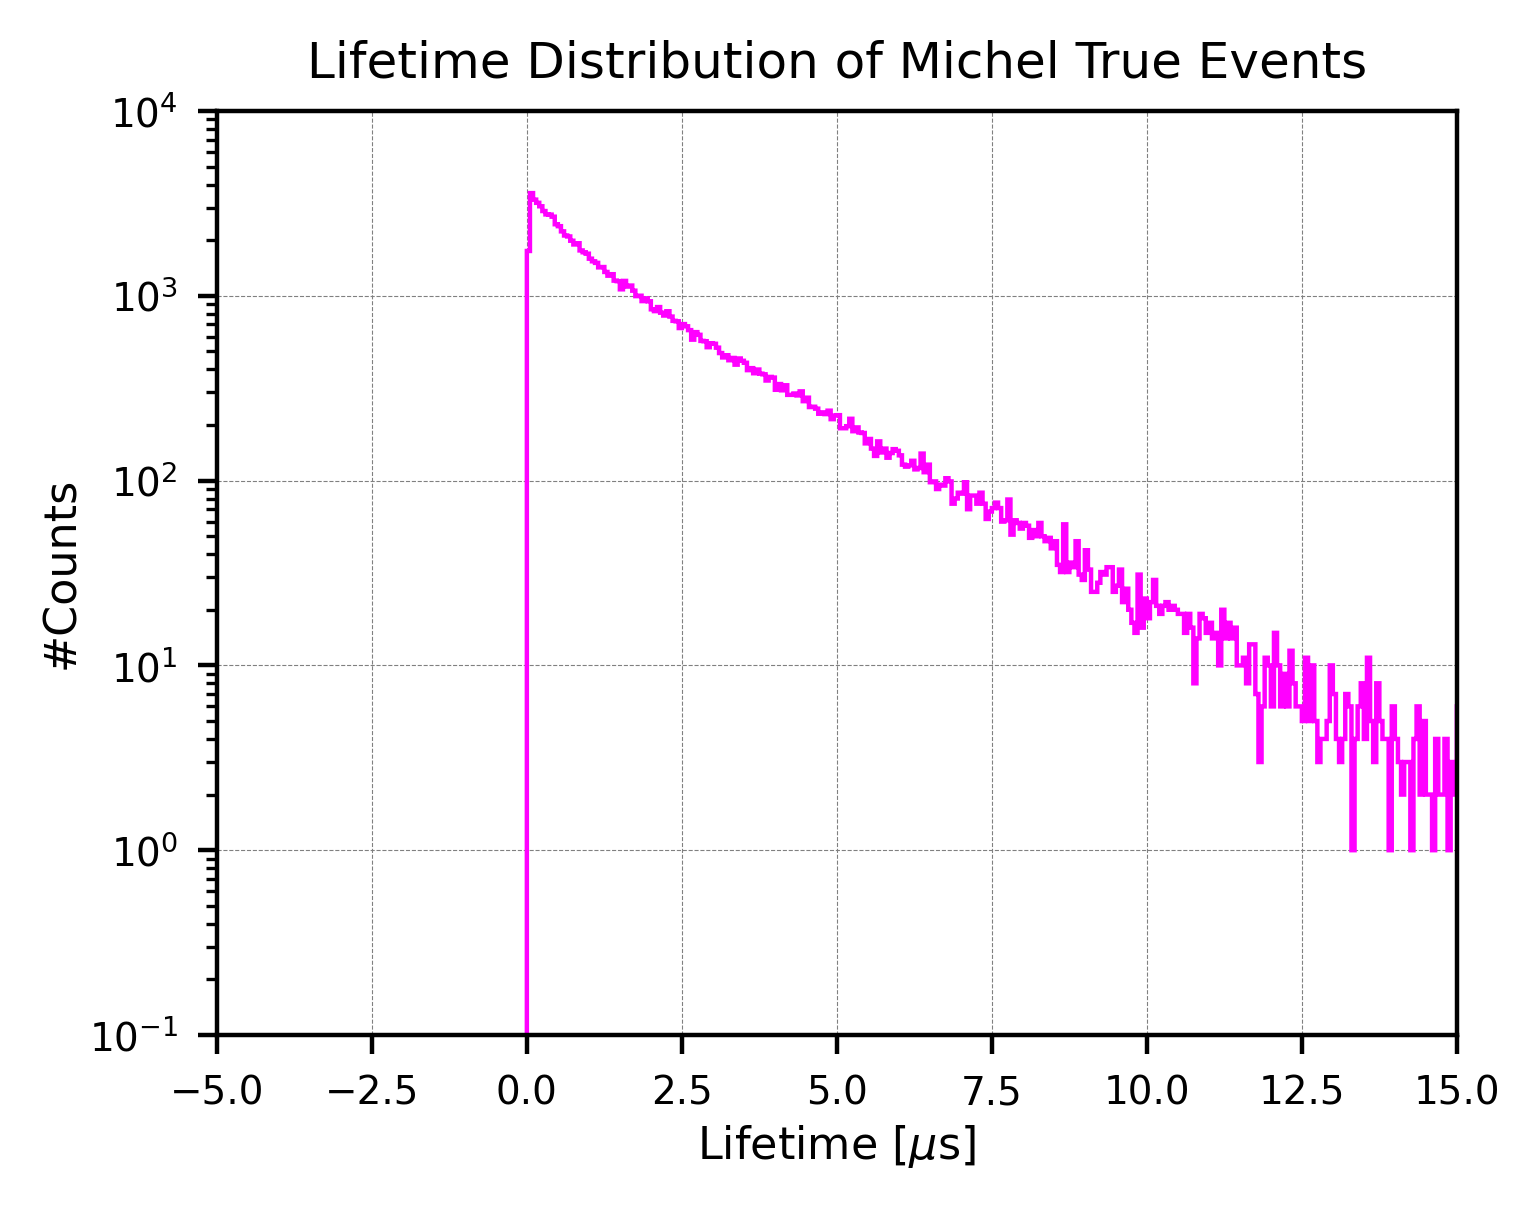

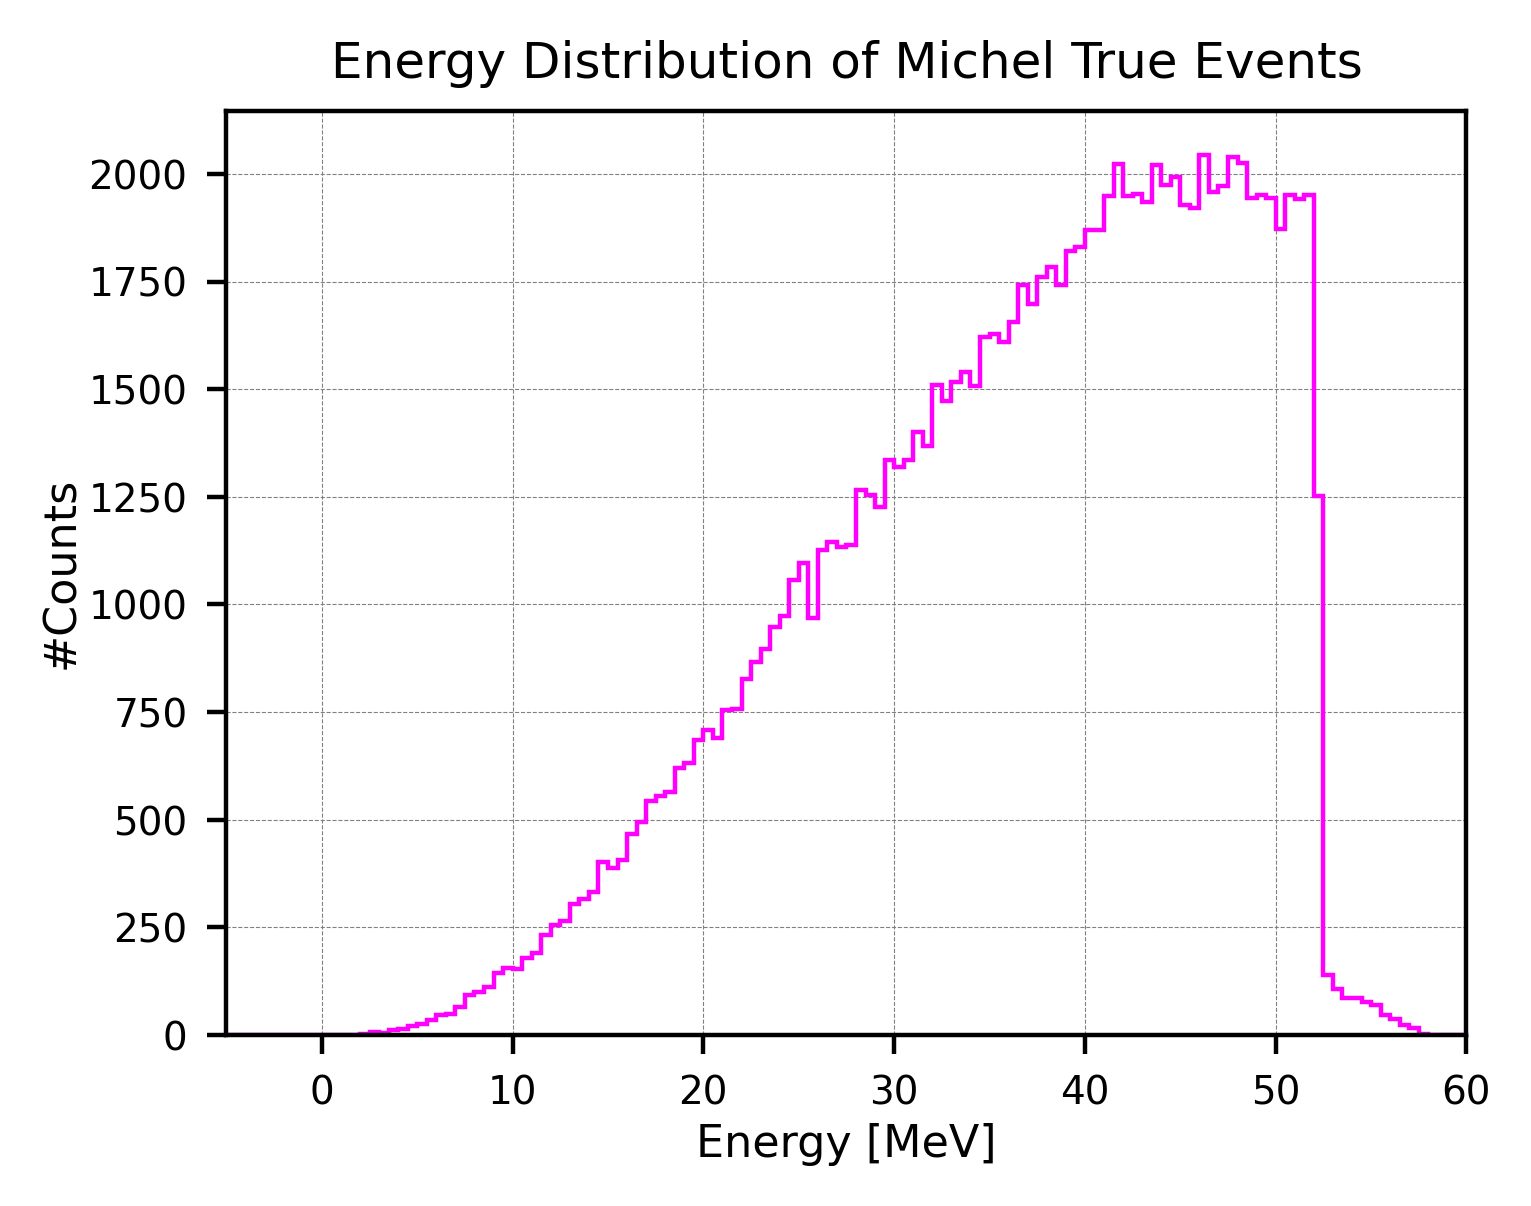

In [ ]:

TPC_lifetime_true = [ev.lifetime_initial for ev in TPC_events_true]
TPC_energy_true = [ev.energy_initial for ev in TPC_events_true]


#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_lifetime_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 15)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.ylim(0.1, 10000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()  










#True Energy distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.5
range_min = -20
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(TPC_energy_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 60)
plt.xlabel('Energy [MeV]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 10000)
#plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Energy Distribution of Michel True Events', fontsize=9)
plt.show()  


### New fittings:

(TPC cut) Michel e^+  :  90370 / 150427 (60.08%)
(TPC cut) Michel e^-  :  19488 / 150427 (12.96%)
(TPC cut) False Michel:  19488 / 150427 (12.96%)


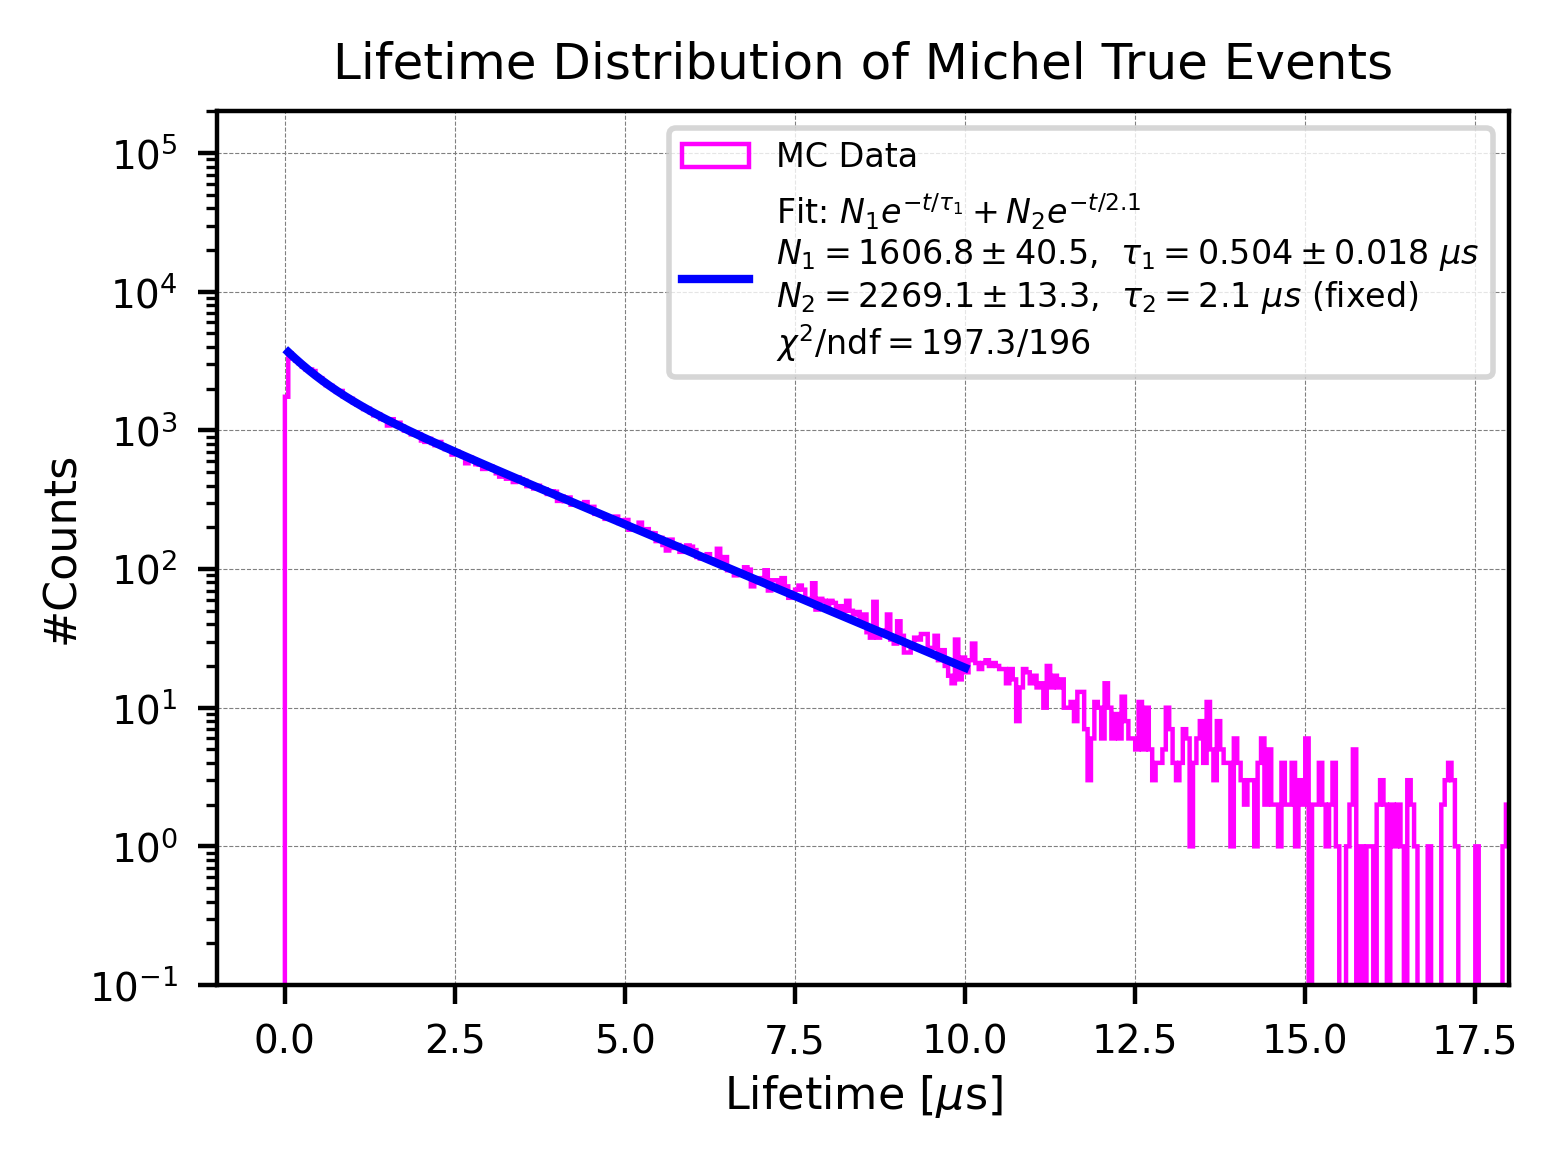

N1 = 1606.770 ± 40.531
tau1 = 0.50400 ± 0.01756 us
N2 = 2269.055 ± 13.292
chi2/ndf = 197.27/196 = 1.006


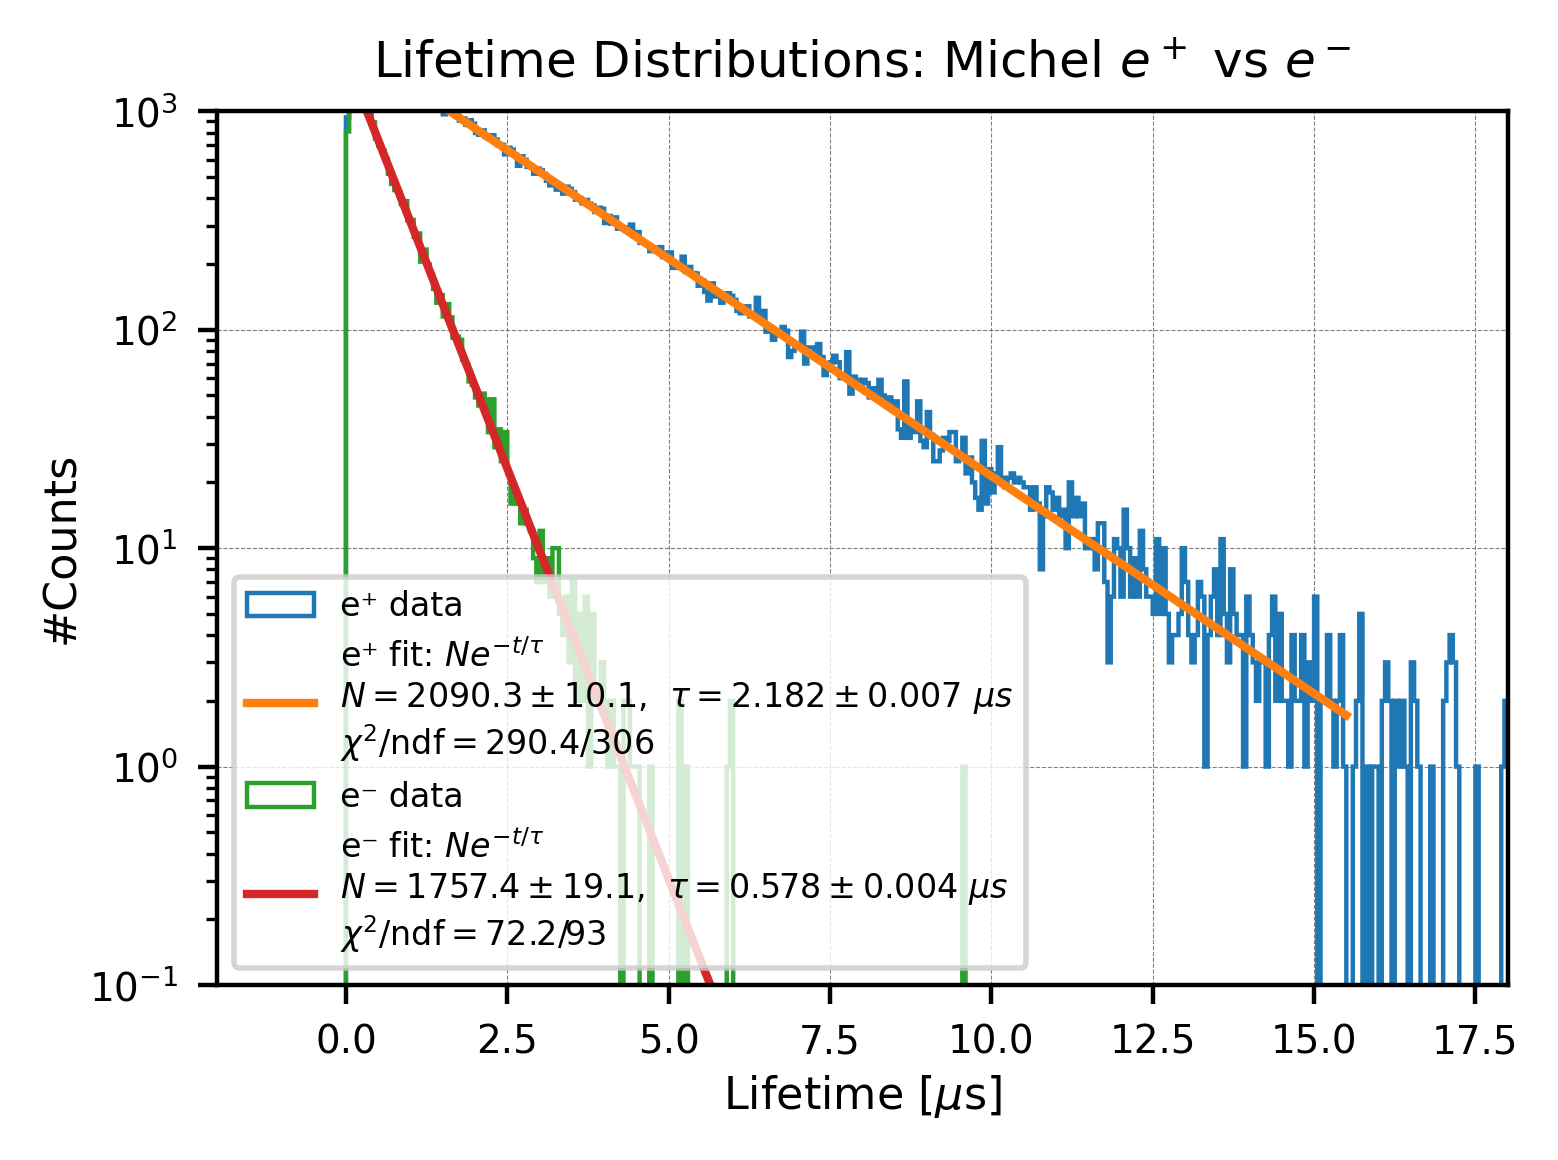

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit



# Seperate Michel e^- and e^+ (true events)------------------------------
TPC_life_pM = []
TPC_life_nM = []
count = 0
for ev in TPC_events_reco:
    pdg = ev.pdg_initial
    life = ev.lifetime_initial

    if pdg < 0:
        TPC_life_pM.append(life)
    elif pdg > 0:
        TPC_life_nM.append(life)
    elif pdg == 0:
        count += 1

print("(TPC cut) Michel e^+  : ", len(TPC_life_pM), "/", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_life_pM)/len(TPC_events_reco)*100))
print("(TPC cut) Michel e^-  : ", len(TPC_life_nM), "/", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_life_nM)/len(TPC_events_reco)*100))
print("(TPC cut) False Michel: ", len(TPC_life_nM), "/", len(TPC_events_reco), 
      "({:.2f}%)".format(len(TPC_life_nM)/len(TPC_events_reco)*100))








# Define the new exponential decay function===========================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ============================================================
# Exponential decay model (bin-by-bin, tau2 fixed)
# ============================================================
def exp_decay(t, N1, tau1, N2):
    return N1 * np.exp(-t / tau1) + N2 * np.exp(-t / 2.1)

# ============================================================
# Histogram setup
# ============================================================
plt.figure(figsize=(4, 3), dpi=400)
bin_width = 0.05
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Histogram the data
counts, bin_edges = np.histogram(TPC_lifetime_true, bins=bins, range=(range_min, range_max))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# ============================================================
# Select fitting region
# ============================================================
fit_mask = (bin_centers >= 0.05) & (bin_centers <= 10)
x_fit_all = bin_centers[fit_mask]
y_fit_all = counts[fit_mask]

# Skip zero bins (avoid div by 0 in weights)
nz = y_fit_all > 0
x_fit = x_fit_all[nz]
y_fit = y_fit_all[nz]
sigma = np.sqrt(y_fit)  # Poisson errors

# ============================================================
# Initial guesses
# ============================================================
N1_0 = float(np.max(y_fit)) if y_fit.size else 1.0
tau1_0 = 2.0
N2_0 = max(N1_0 / 10.0, 1.0)

# ============================================================
# Weighted least squares fit
# ============================================================
popt, pcov = curve_fit(
    exp_decay, x_fit, y_fit,
    p0=[N1_0, tau1_0, N2_0],
    sigma=sigma,
    absolute_sigma=True,
    bounds=([0.0, 0.0, 0.0], [np.inf, np.inf, np.inf]),
    maxfev=20000,
)
N1_fit, tau1_fit, N2_fit = popt
perr = np.sqrt(np.diag(pcov))
N1_err, tau1_err, N2_err = perr

# ============================================================
# Chi² / ndf
# ============================================================
y_exp = exp_decay(x_fit, *popt)
residual = (y_fit - y_exp) / sigma
chi2 = np.sum(residual**2)
ndf = max(len(x_fit) - len(popt), 1)
chi2_ndf = chi2 / ndf

# ============================================================
# Smooth curve for plotting
# ============================================================
x_smooth = np.linspace(0.05, 10, 500)
y_smooth = exp_decay(x_smooth, *popt)

# ============================================================
# Plot histogram
# ============================================================
plt.hist(TPC_lifetime_true, bins=bins, range=(range_min, range_max),
         edgecolor='magenta', histtype='step', linewidth=0.8, label="MC Data")

# Plot fitted curve
plt.plot(
    x_smooth, y_smooth, 'b-',
    label=(
        r'Fit: $N_1 e^{-t/\tau_1} + N_2 e^{-t/2.1}$' + '\n'
        + rf'$N_1={N1_fit:.1f}\pm{N1_err:.1f}$,  $\tau_1={tau1_fit:.3f}\pm{tau1_err:.3f}\ \mu s$' + '\n'
        + rf'$N_2={N2_fit:.1f}\pm{N2_err:.1f}$,  $\tau_2=2.1\ \mu s$ (fixed)' + '\n'
        + rf'$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$'
    )
)

# ============================================================
# Style
# ============================================================
plt.xlim(-1, 18)
plt.ylim(0.1, 200000)
plt.yscale('log')
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.legend(fontsize=6)
plt.tight_layout()
plt.show()

# ============================================================
# Print results
# ============================================================
print(
    f"N1 = {N1_fit:.3f} ± {N1_err:.3f}\n"
    f"tau1 = {tau1_fit:.5f} ± {tau1_err:.5f} us\n"
    f"N2 = {N2_fit:.3f} ± {N2_err:.3f}\n"
    f"chi2/ndf = {chi2:.2f}/{ndf} = {chi2_ndf:.3f}"
)













#Fitting seperating for Michel e^+ and e^-===============================================

# --- single exponential ---
def exp1(t, N, tau):
    return N * np.exp(-t / tau)

# --- plotting / binning setup ---
plt.figure(figsize=(4, 3), dpi=400)
bin_width = 0.05
range_min, range_max = -20, 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

# --- helper: weighted fit (σ = sqrt(y)), skip zeros, draw ---
def fit_and_draw(sample, label_prefix, fit_range=(0.05, 15.5)):
    # histogram
    counts, bin_edges = np.histogram(sample, bins=bins, range=(range_min, range_max))
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # choose fit window & drop zero bins
    m = (bin_centers >= fit_range[0]) & (bin_centers <= fit_range[1])
    x_all = bin_centers[m]
    y_all = counts[m]
    nz = y_all > 0
    x_fit = x_all[nz]
    y_fit = y_all[nz]

    # abort gracefully if too few points
    if len(y_fit) < 3:
        plt.hist(sample, bins=bins, range=(range_min, range_max),
                 histtype='step', linewidth=0.8, label=f"{label_prefix} MC data")
        return (np.nan, np.nan, np.nan, np.nan, np.nan)

    sigma = np.sqrt(y_fit)

    # safe initial guesses & bounds
    N0, tau0 = float(np.max(y_fit)), 2.0
    bounds = ([0.0, 1e-6], [np.inf, np.inf])

    # weighted least squares
    popt, pcov = curve_fit(
        exp1, x_fit, y_fit, p0=[N0, tau0],
        sigma=sigma, absolute_sigma=True,
        bounds=bounds, maxfev=20000
    )
    N_fit, tau_fit = popt
    N_err, tau_err = np.sqrt(np.diag(pcov))

    # chi2/ndf
    y_mod = exp1(x_fit, *popt)
    r = (y_fit - y_mod) / sigma
    chi2 = float(np.sum(r**2))
    ndf = max(len(x_fit) - len(popt), 1)
    chi2_ndf = chi2 / ndf

    # smooth curve
    x_smooth = np.linspace(fit_range[0], fit_range[1], 500)
    y_smooth = exp1(x_smooth, *popt)

    # draw histogram (step)
    plt.hist(sample, bins=bins, range=(range_min, range_max),
             histtype='step', linewidth=0.8, label=f"{label_prefix} data")

    # draw fit
    plt.plot(
        x_smooth, y_smooth,
        label=(fr"{label_prefix} fit: $Ne^{{-t/\tau}}$" + "\n"
               + rf"$N={N_fit:.1f}\pm{N_err:.1f}$,  $\tau={tau_fit:.3f}\pm{tau_err:.3f}\ \mu s$" + "\n"
               + rf"$\chi^2/\mathrm{{ndf}} = {chi2:.1f}/{ndf}$")
    )

    return (N_fit, tau_fit, N_err, tau_err, chi2_ndf)

# ---- run for both lists ----
N_p, tau_p, dN_p, dtau_p, chi2ndf_p = fit_and_draw(np.asarray(TPC_life_pM), "e⁺")
N_n, tau_n, dN_n, dtau_n, chi2ndf_n = fit_and_draw(np.asarray(TPC_life_nM), "e⁻")

# --- final plot cosmetics (kept similar to your style) ---
plt.xlim(-2, 18)
plt.ylim(0.1, 1000)
plt.yscale('log')
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.tick_params(labelsize=7)
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distributions: Michel $e^+$ vs $e^-$', fontsize=9)
plt.legend(fontsize=6)
plt.tight_layout()
plt.show()





<br />
<br />
<br />
<br />
<br />
<br />
<br />
<br />

# Part II: Evaluate BKG Sample
pos5GeV & pos1GeV: MS<0.1 &MH<3 (Here from initial_print, NO TPC cuts)

In [20]:
from dataclasses import dataclass
import os


# ----------------------------- Configuration --------------------------------
data_groups_bkg = [
    {
        "data_dir": "./statResult_tpc",
        "dates": [
            "bkg_pos1GeV_part1", "bkg_pos1GeV_part2", "bkg_pos1GeV_part3", 
            "bkg_pos5GeV_part1", "bkg_pos5GeV_part2", "bkg_pos5GeV_part3"
        ]
    }
]



# ----------------------------- File Reading ---------------------------------
data_bkg = {k: [] for k in fields_info}  # initialize empty lists for each field

for group in data_groups_bkg:
    data_dir = group["data_dir"]
    dates_all = group["dates"]

    print(f"\n[INFO] Reading group: {data_dir}")
    for field, (stub, cast_type) in fields_info.items():

        for d in dates_all:
            file_path = f"{data_dir}/{stub}_{d}_initial.txt"
            vals = read_values(file_path, cast_type)

            data_bkg[field].extend(vals)
            print(f"  - Loaded {len(vals):6d} entries from {d} → appended to {field}")

print("\n[INFO] Combined totals:")
for field in data_bkg:
    print(f"  {field}: {len(data_bkg[field])} entries")


# ----------------------------- Build Events ---------------------------------
n_events = len(next(iter(data_bkg.values())))
events_reco_bkg = [
    ParticleEvent(**{k: data_bkg[k][i] for k in data_bkg})
    for i in range(n_events)
]

print(f"\n[OK] Created {len(events_reco_bkg)} ParticleEvent objects.")


print("Candidates ( MH > xxx): ", len(events_reco_bkg))

print("\nExample: ")
print(events_reco_bkg[0].decayX_initial)
print(events_reco_bkg[0].energy_initial)
print(events_reco_bkg[0].pdg_initial)




# ----------------------------- Create Lists for Direct Access ----------------
# Create standalone lists (just like your old style)
decayX_initial_bkg   = data_bkg["decayX_initial"]
decayY_initial_bkg   = data_bkg["decayY_initial"]
decayZ_initial_bkg   = data_bkg["decayZ_initial"]
startX_initial_bkg   = data_bkg["startX_initial"]
startY_initial_bkg   = data_bkg["startY_initial"]
startZ_initial_bkg   = data_bkg["startZ_initial"]
MS_initial_bkg       = data_bkg["MS_initial"]
MH_initial_bkg       = data_bkg["MH_initial"]
energy_initial_bkg   = data_bkg["energy_initial"]
lifetime_initial_bkg = data_bkg["lifetime_initial"]
pdg_initial_bkg      = data_bkg["pdg_initial"]
eventID_initial_bkg  = data_bkg["eventID_initial"]
trackID_initial_bkg  = data_bkg["trackID_initial"]





#True Michel events----------
events_true_bkg = []
trueE_num = 0
trueL_num = 0
for ev in events_reco_bkg:
    if ev.energy_initial > 0:
        trueE_num += 1
        events_true_bkg.append(ev)
    if ev.lifetime_initial > 0:
        trueL_num += 1

print("\n# of True events: ", len(events_true_bkg))
print("Events with E > 0 (true Michel): ", trueE_num, "({:.2f}%)".format(trueE_num/len(events_reco_bkg)*100))
print("Events with L > 0 (true Michel): ", trueL_num, "({:.2f}%)".format(trueL_num/len(events_reco_bkg)*100))




[INFO] Reading group: ./statResult_tpc
  - Loaded 148509 entries from bkg_pos1GeV_part1 → appended to decayX_initial
  - Loaded 149221 entries from bkg_pos1GeV_part2 → appended to decayX_initial
  - Loaded  90522 entries from bkg_pos1GeV_part3 → appended to decayX_initial
  - Loaded 144553 entries from bkg_pos5GeV_part1 → appended to decayX_initial
  - Loaded 144600 entries from bkg_pos5GeV_part2 → appended to decayX_initial
  - Loaded  82474 entries from bkg_pos5GeV_part3 → appended to decayX_initial
  - Loaded 148509 entries from bkg_pos1GeV_part1 → appended to decayY_initial
  - Loaded 149221 entries from bkg_pos1GeV_part2 → appended to decayY_initial
  - Loaded  90522 entries from bkg_pos1GeV_part3 → appended to decayY_initial
  - Loaded 144553 entries from bkg_pos5GeV_part1 → appended to decayY_initial
  - Loaded 144600 entries from bkg_pos5GeV_part2 → appended to decayY_initial
  - Loaded  82474 entries from bkg_pos5GeV_part3 → appended to decayY_initial
  - Loaded 148509 entrie


Decay points distribution: 
# of X < 0 :  11716 (52.54%)
# of X >= 0:  10583 (47.46%)


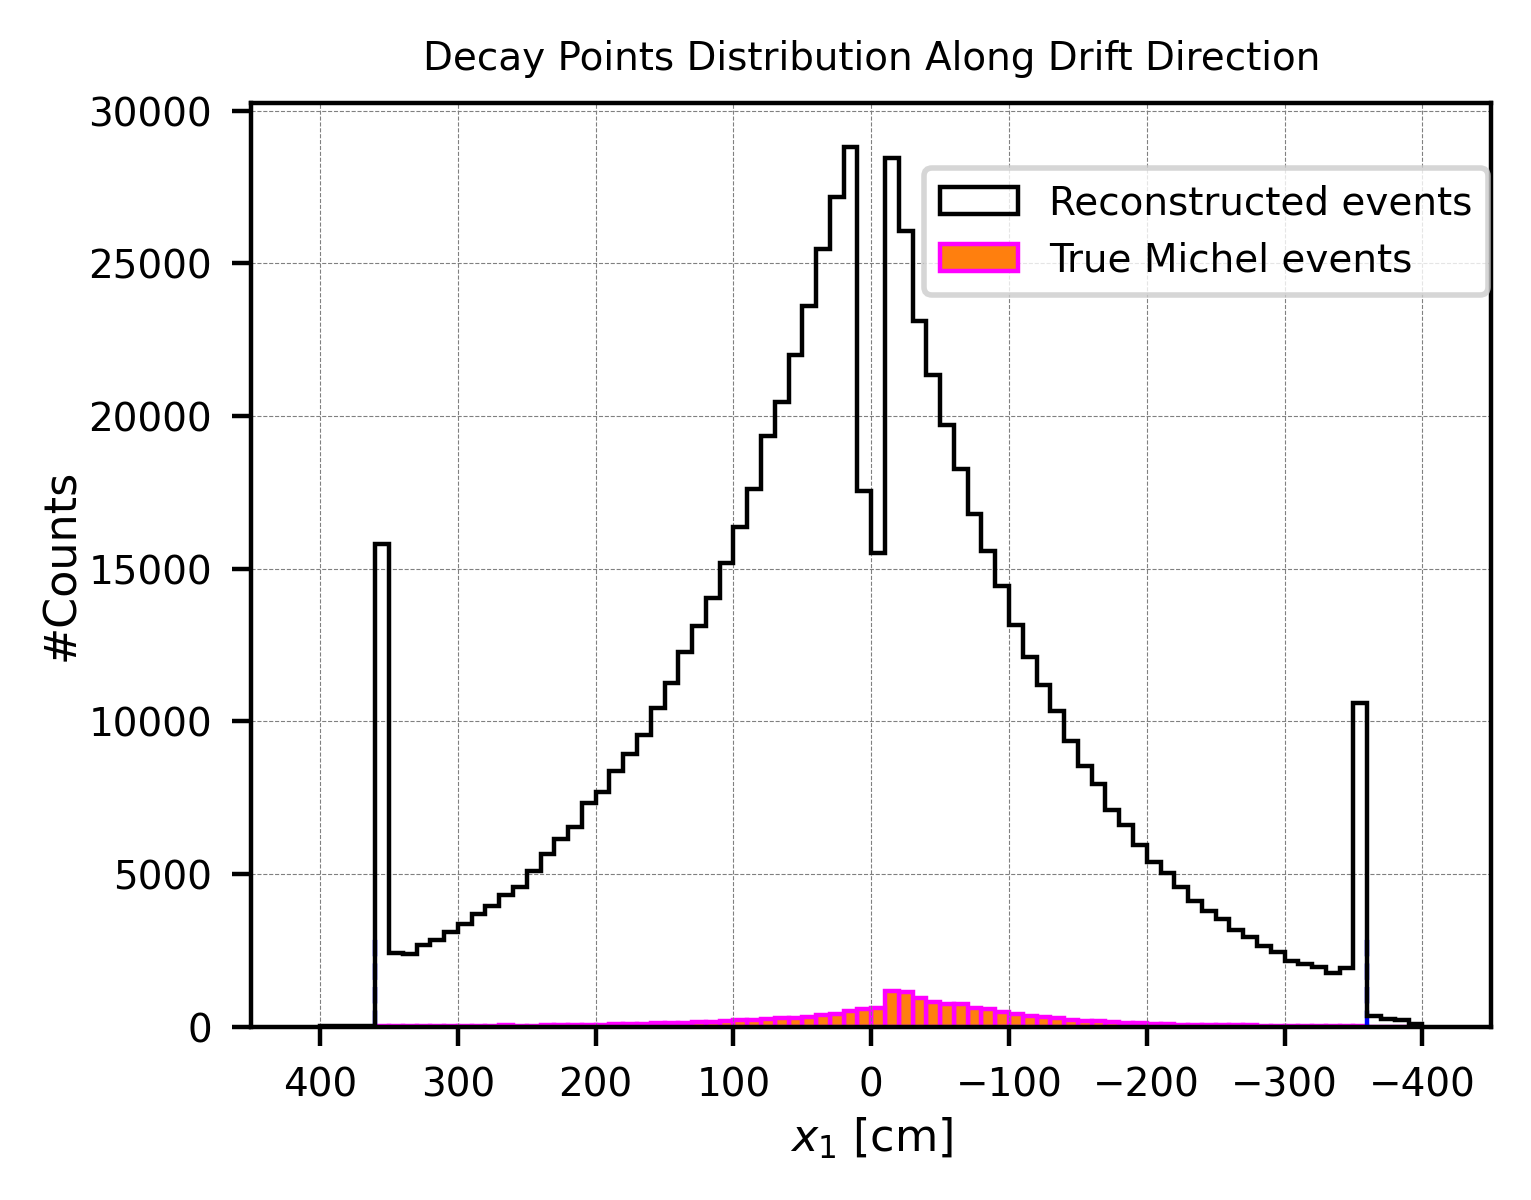

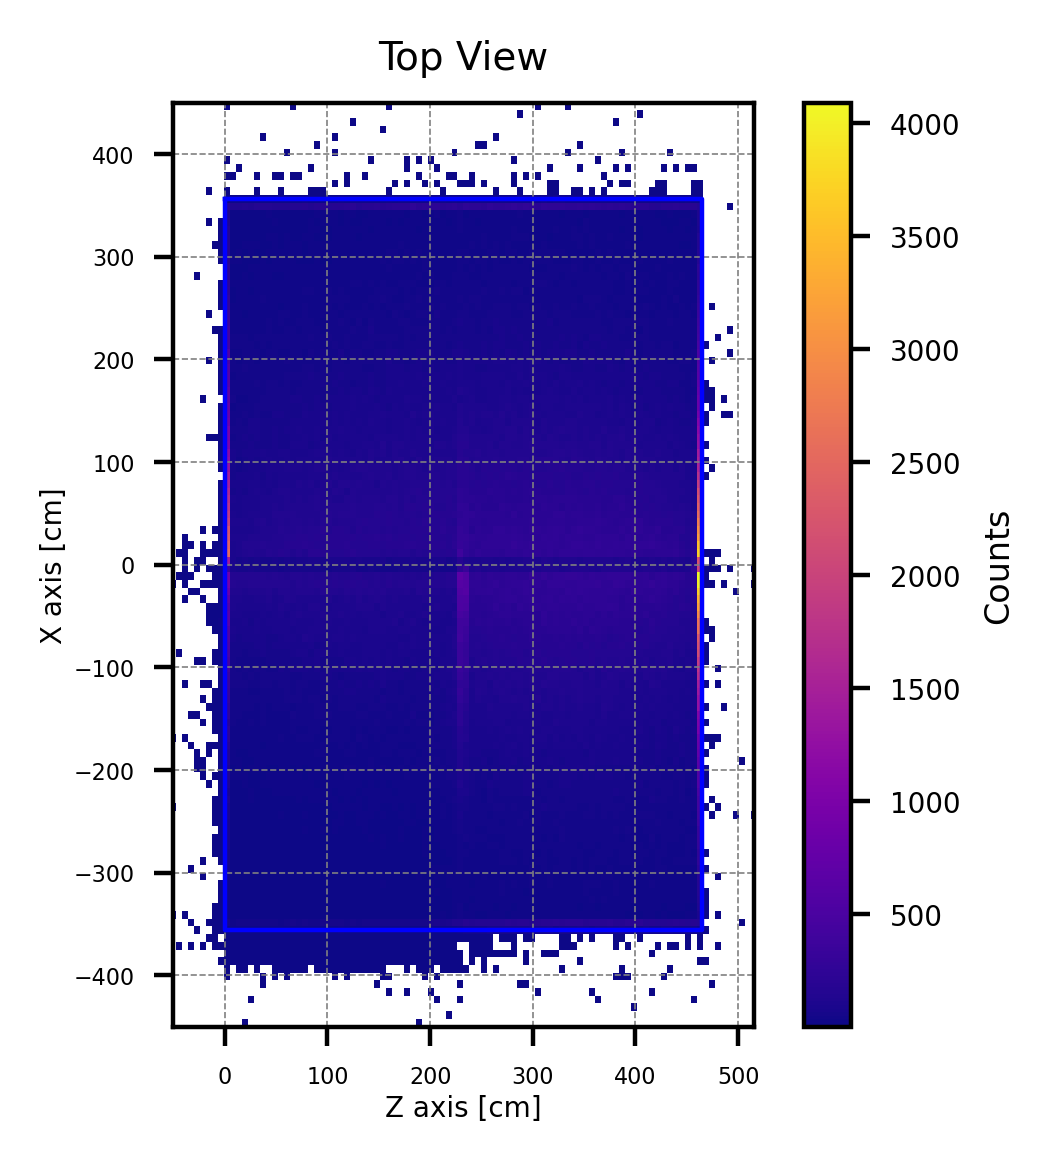

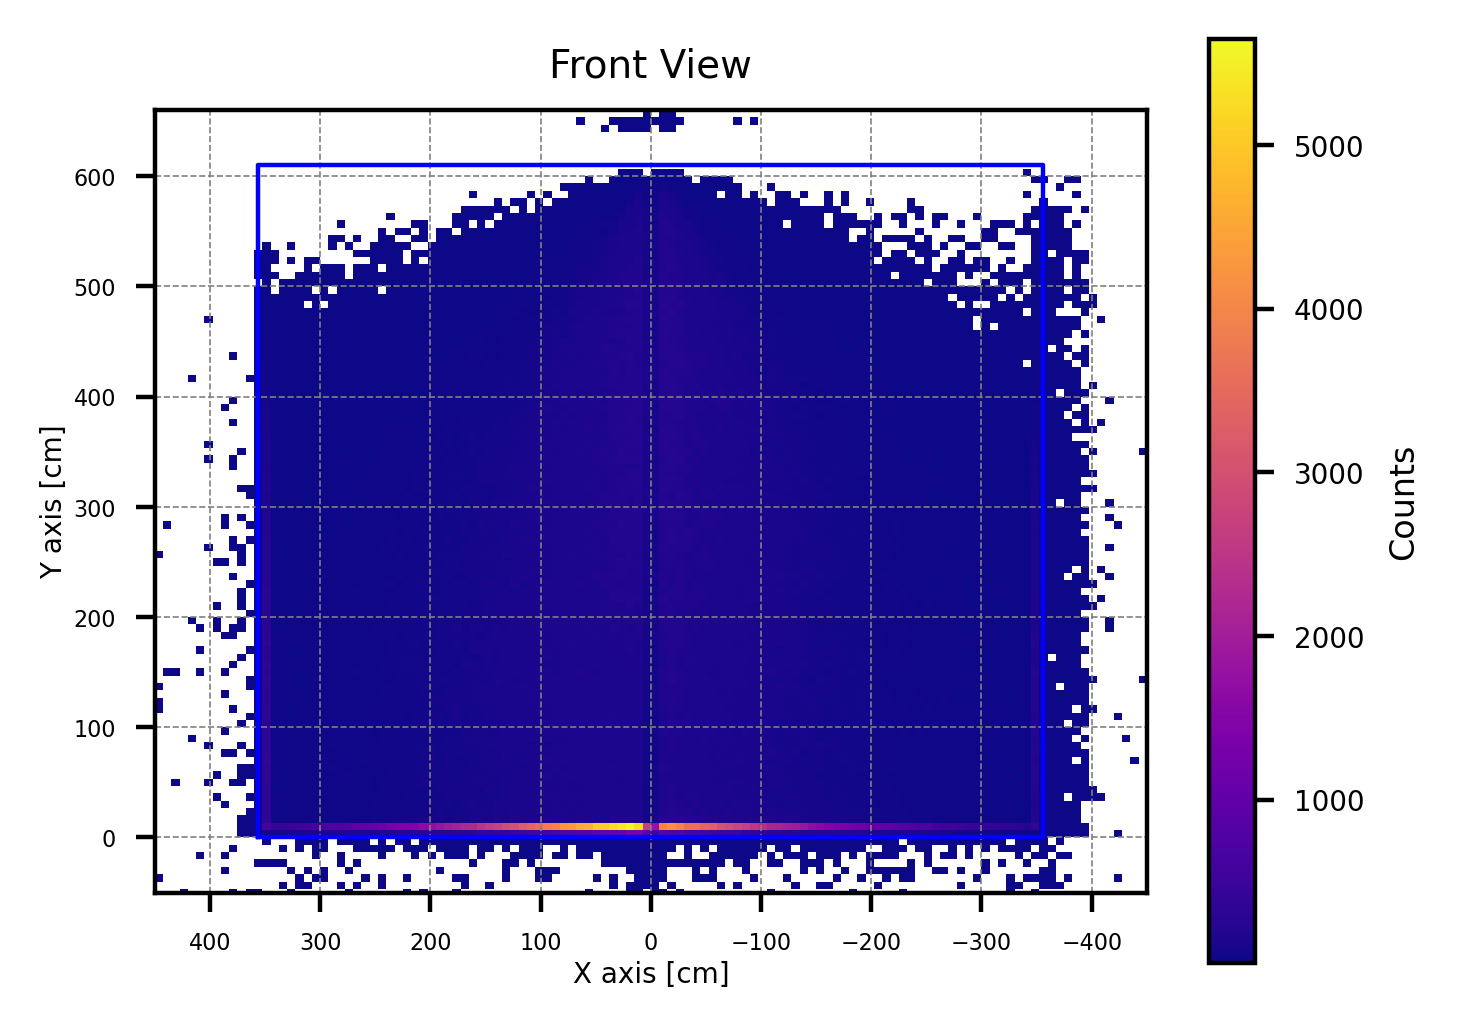

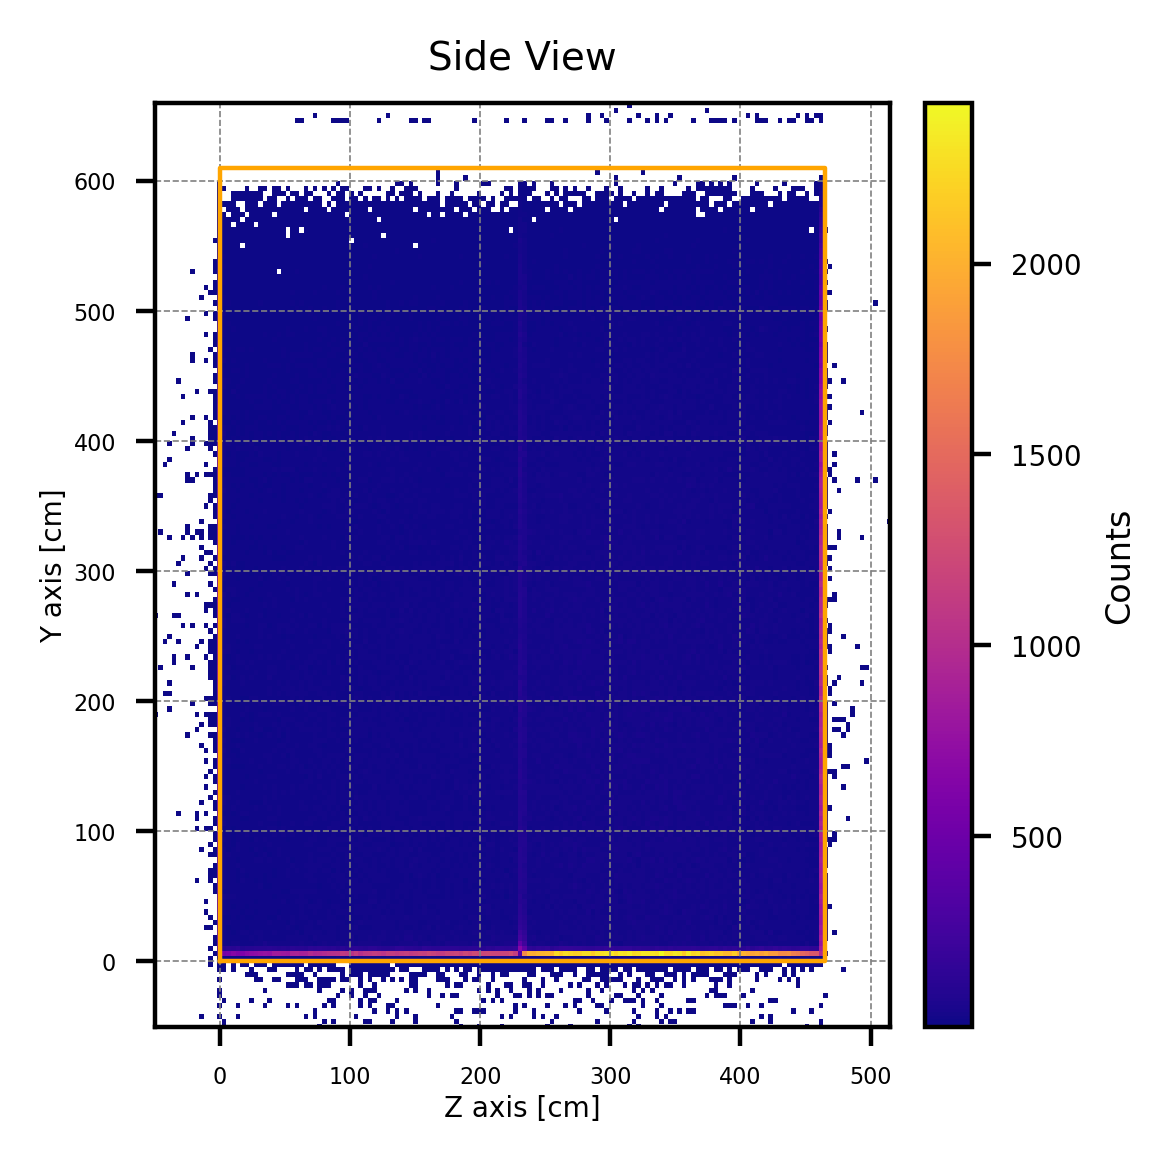


min(vals_MS_initial) 0.0
MS<0.01:  704662 / 759879 (92.73%)


<Figure size 1600x1200 with 0 Axes>

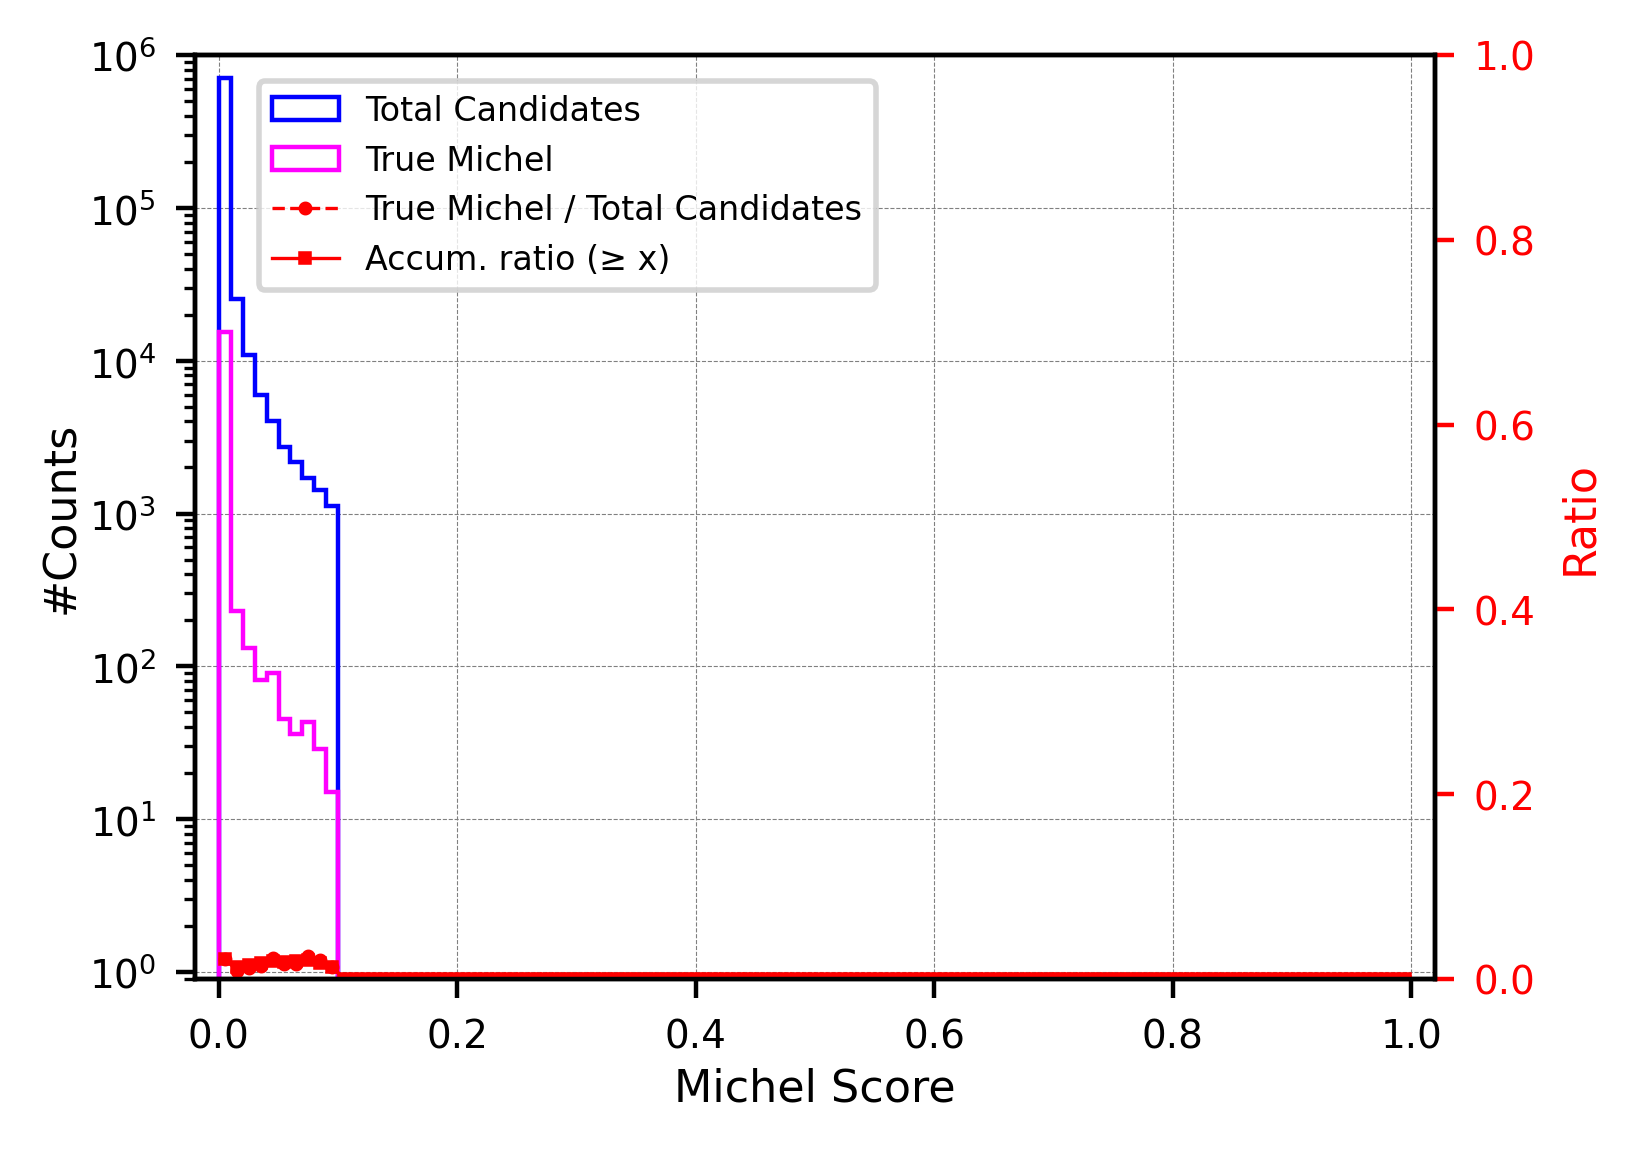

<Figure size 1600x1200 with 0 Axes>

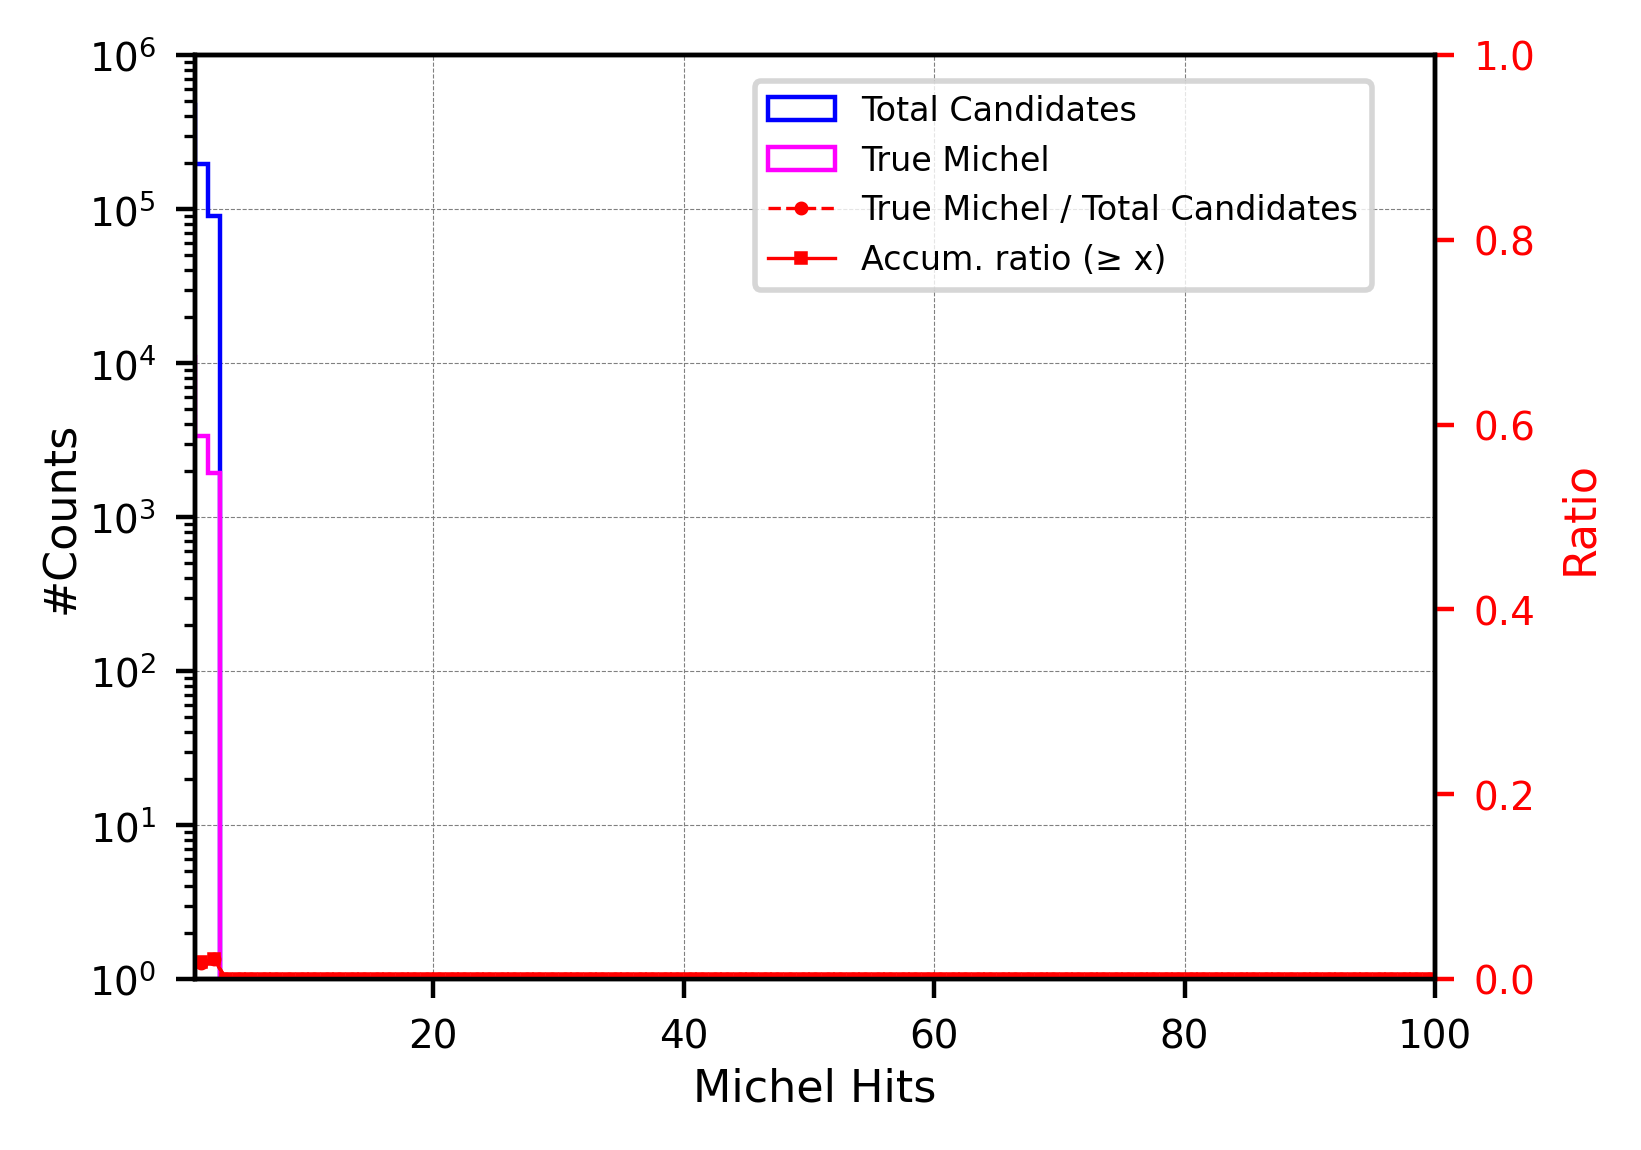

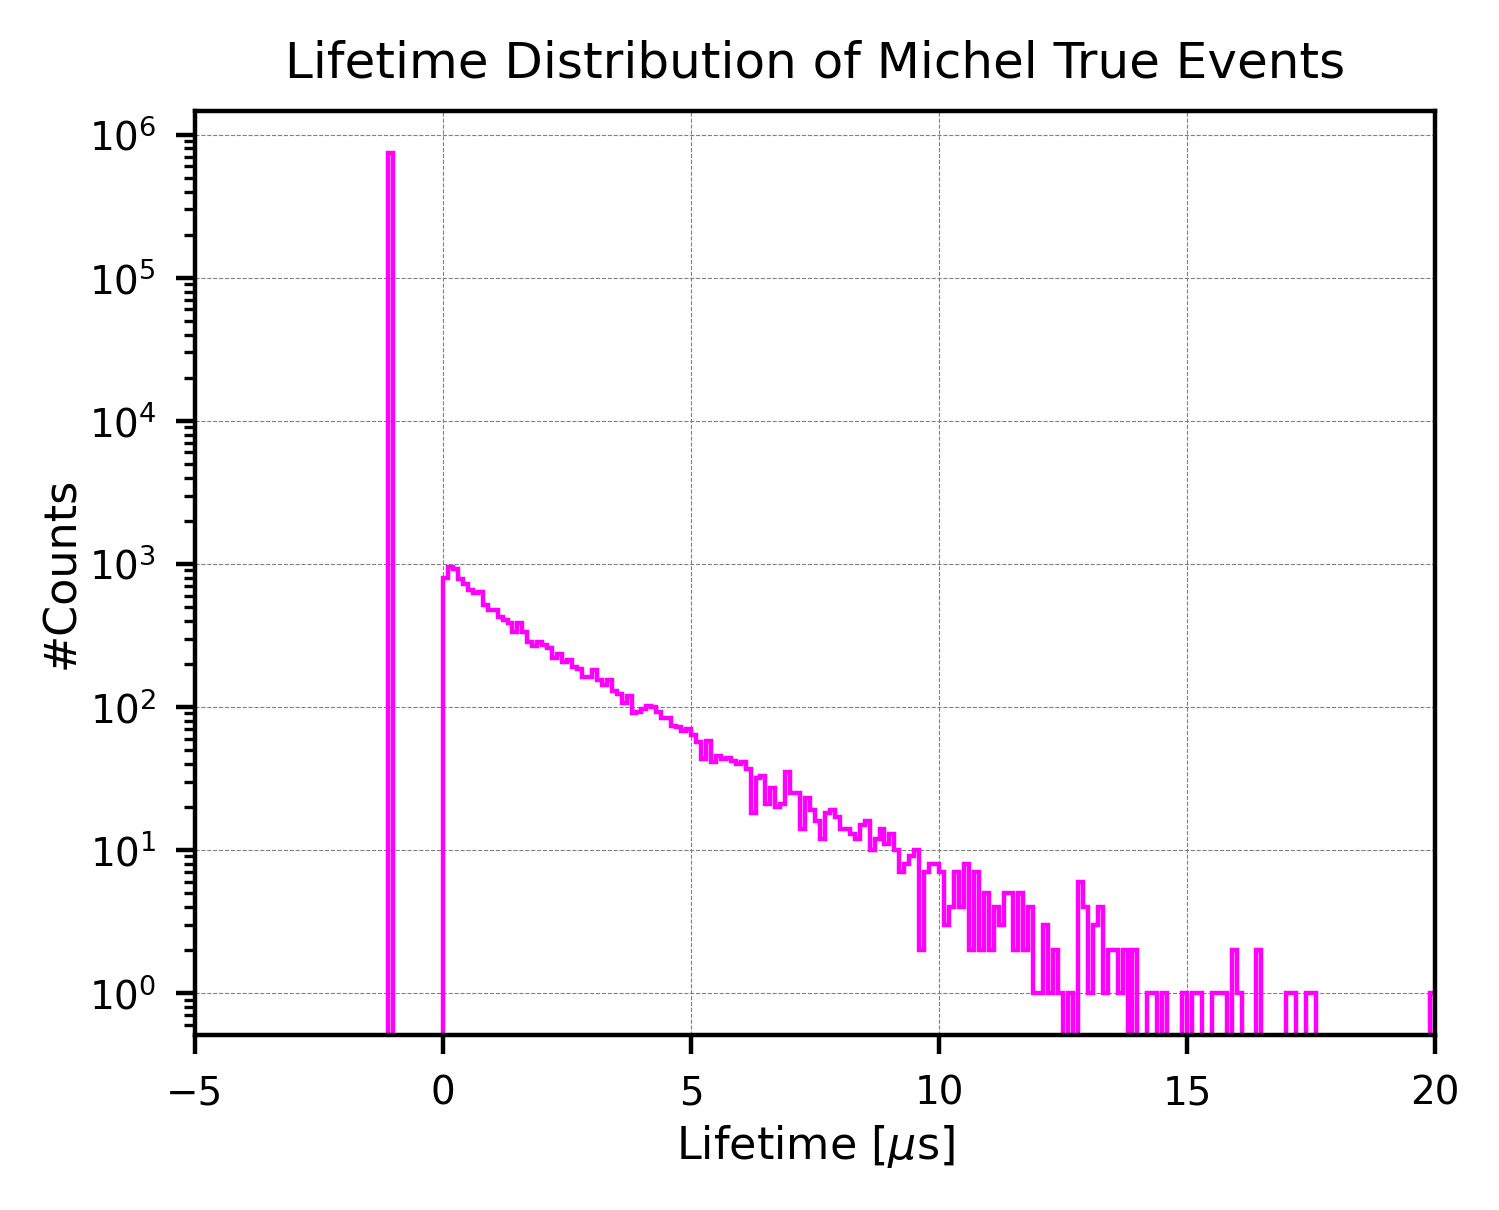

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in events_reco_bkg]
vals_decayY_initial = [ev.decayY_initial for ev in events_reco_bkg]
vals_decayZ_initial = [ev.decayZ_initial for ev in events_reco_bkg]
vals_MS_initial = [ev.MS_initial for ev in events_reco_bkg]
vals_MH_initial = [ev.MH_initial for ev in events_reco_bkg]
vals_lifetime_initial = [ev.lifetime_initial for ev in events_reco_bkg]

vals_decayX_true = [ev.decayX_initial for ev in events_true_bkg]
vals_MS_true = [ev.MS_initial for ev in events_true_bkg]
vals_MH_true = [ev.MH_initial for ev in events_true_bkg]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(vals_decayX_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 30000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(200, 200), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

print("\n==========================")
print("min(vals_MS_initial)", min(vals_MS_initial))
count = sum(1 for x in vals_MS_initial if x < 0.01)
print("MS<0.01: ", count, "/", len(vals_MS_initial),   "({:.2f}%)".format(count/len(vals_MS_initial)*100))



# Define the range and bin width
bin_width = 0.01
range_min = 0.0 #====================Remember to recover back---
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MS_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([0.5, 0.5], [0, 100000], color="green", linewidth=1.2, linestyle='--')

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02) #(-0.02, 1.02)
ax1.set_ylim(0.9, 1000000)
plt.yscale('log')
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")


# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0, 1.0)
ax2.tick_params(axis='y', labelsize=7, colors='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})


plt.show()








#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MH_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([8, 8], [0, 300000], color="green", linewidth=1.2, linestyle='--')


# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_ylim(1, 1000000)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
plt.yscale('log')
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ax2.set_ylim(0, 1.0)
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")



# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})

plt.show() 








#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_lifetime_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()









<br />
<br />

### Apply Space Cut:

In [22]:

Space_events_reco_bkg = []
Space_events_true_bkg = []



#Selection------
for ev in events_reco_bkg:
    X = ev.decayX_initial
    Y = ev.decayY_initial
    Z = ev.decayZ_initial
    E = ev.energy_initial

    #Default region: 0<y<610, 0<z<465 (SPACE CUT)---
    if -356 < X < 356 and 30 < Y < 580 and 30 < Z < 435:    
        Space_events_reco_bkg.append(ev)
        if E > 0:
            Space_events_true_bkg.append(ev)

                    
                    
                    

                    
#Initial size of dataset:-----
print("Reco events (initial): ", len(events_reco_bkg))
print("True events (initial): ", len(events_true_bkg), "({:.2f}%)".format(len(events_true_bkg)/len(events_reco_bkg)*100))

print("\nReco events (Space cut): ", len(Space_events_reco_bkg), "({:.2f}%)".format(len(Space_events_reco_bkg)/len(events_reco_bkg)*100))
print("True events (Space cut): ", len(Space_events_true_bkg), "({:.2f}%)".format(len(Space_events_true_bkg)/len(Space_events_reco_bkg)*100))






Reco events (initial):  759879
True events (initial):  16189 (2.13%)

Reco events (Space cut):  326352 (42.95%)
True events (Space cut):  13298 (4.07%)



Decay points distribution: 
# of X < 0 :  11716 (52.54%)
# of X >= 0:  10583 (47.46%)


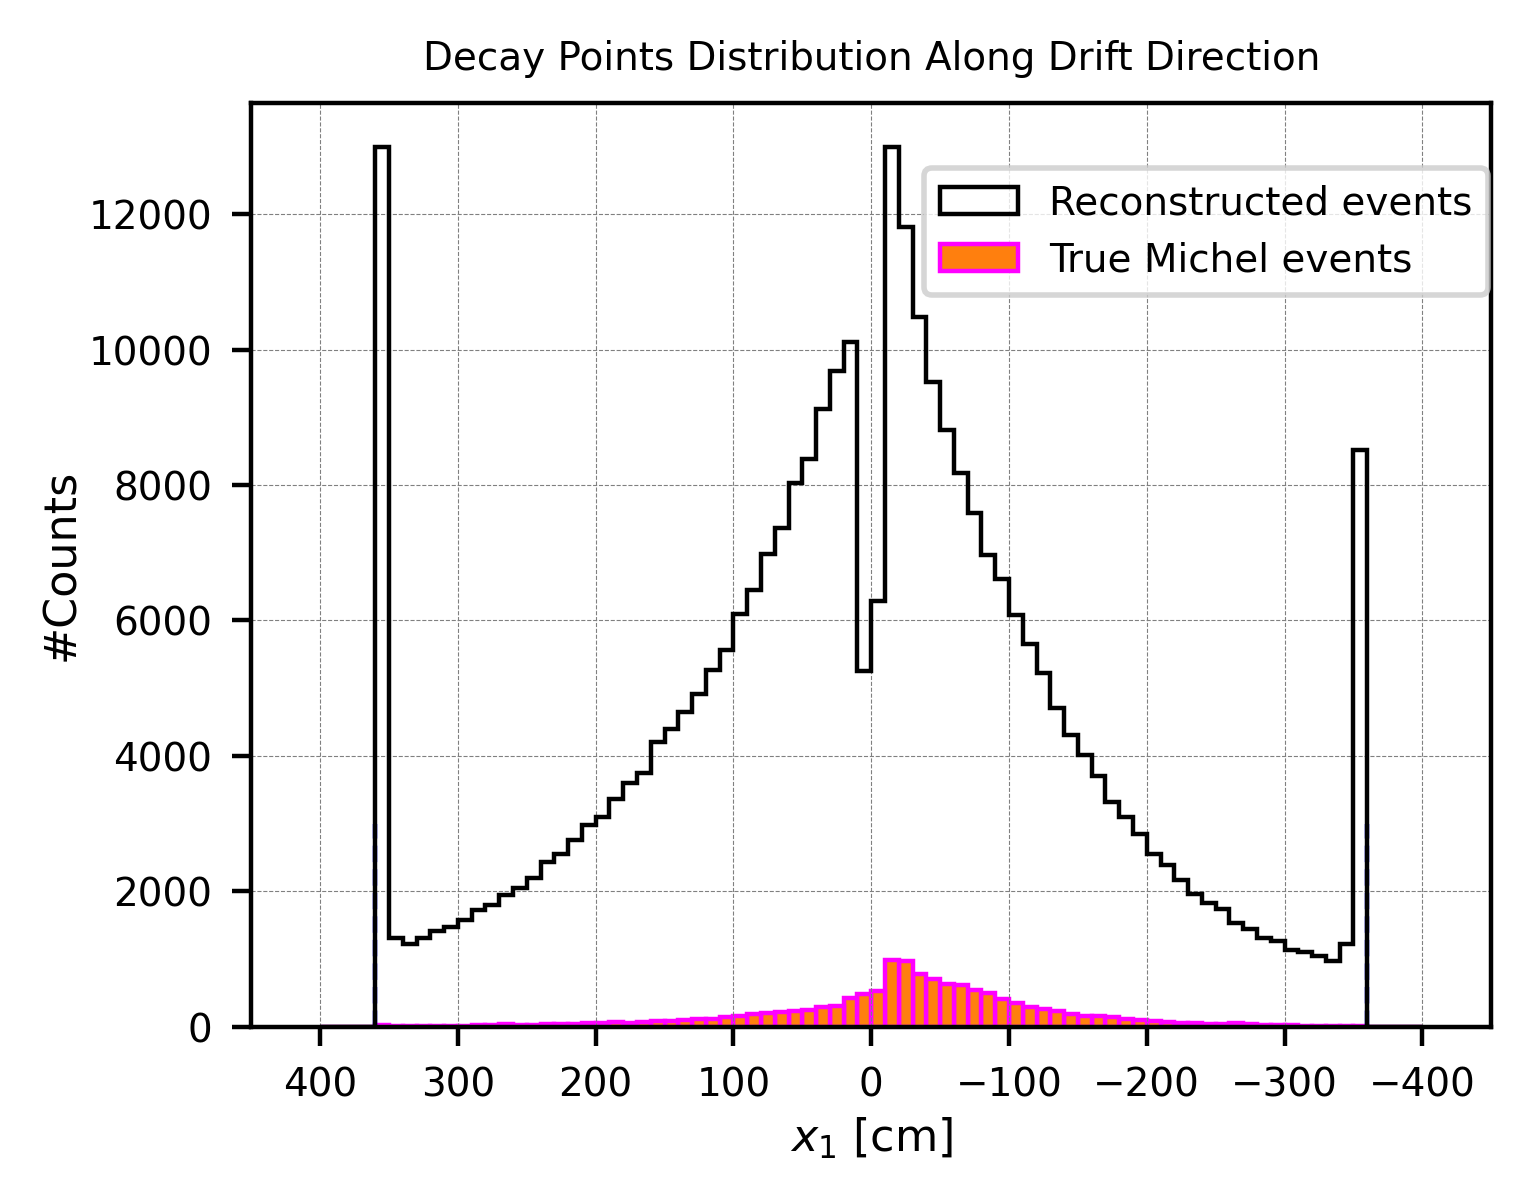

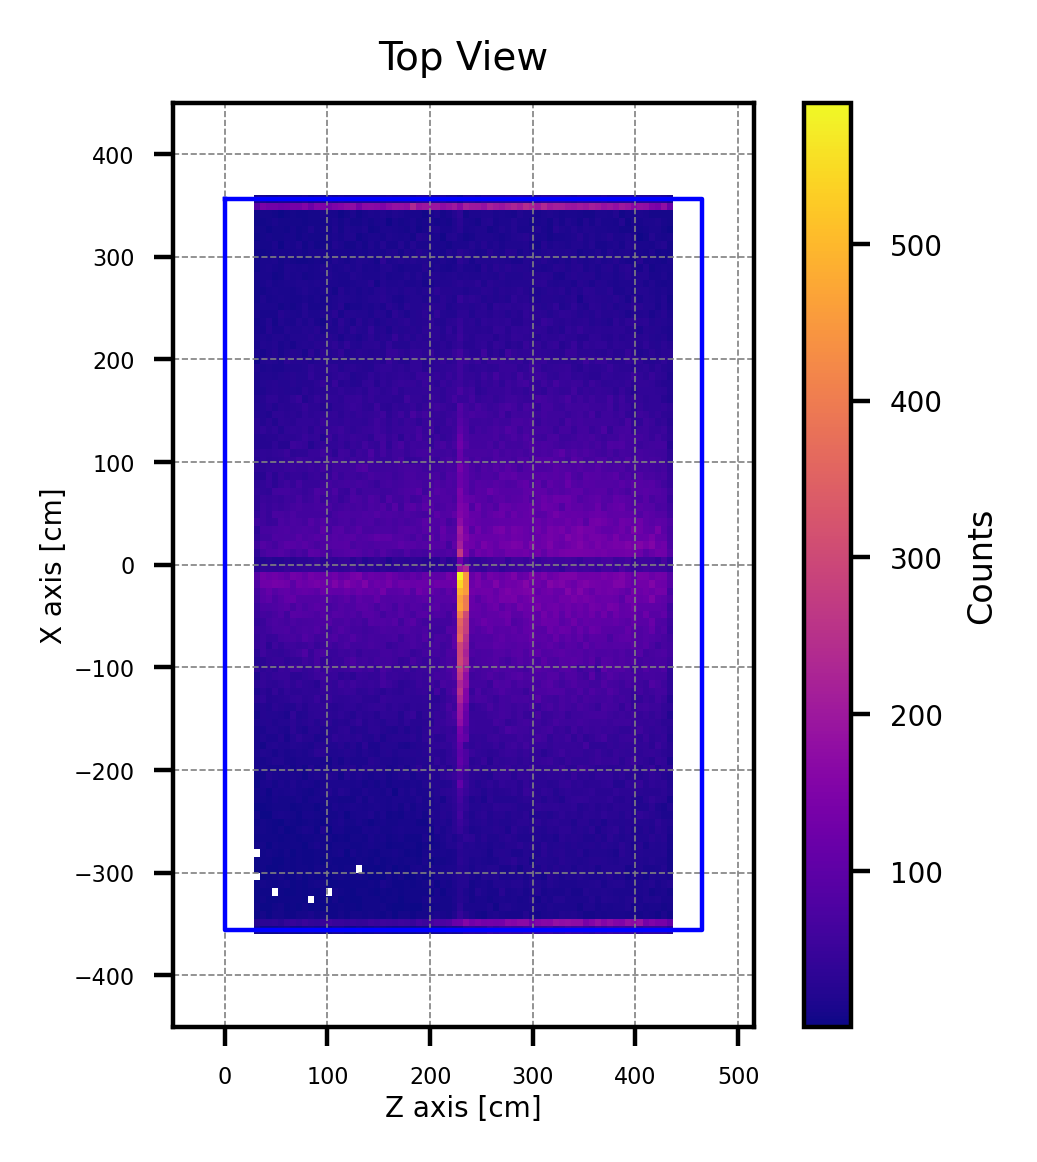

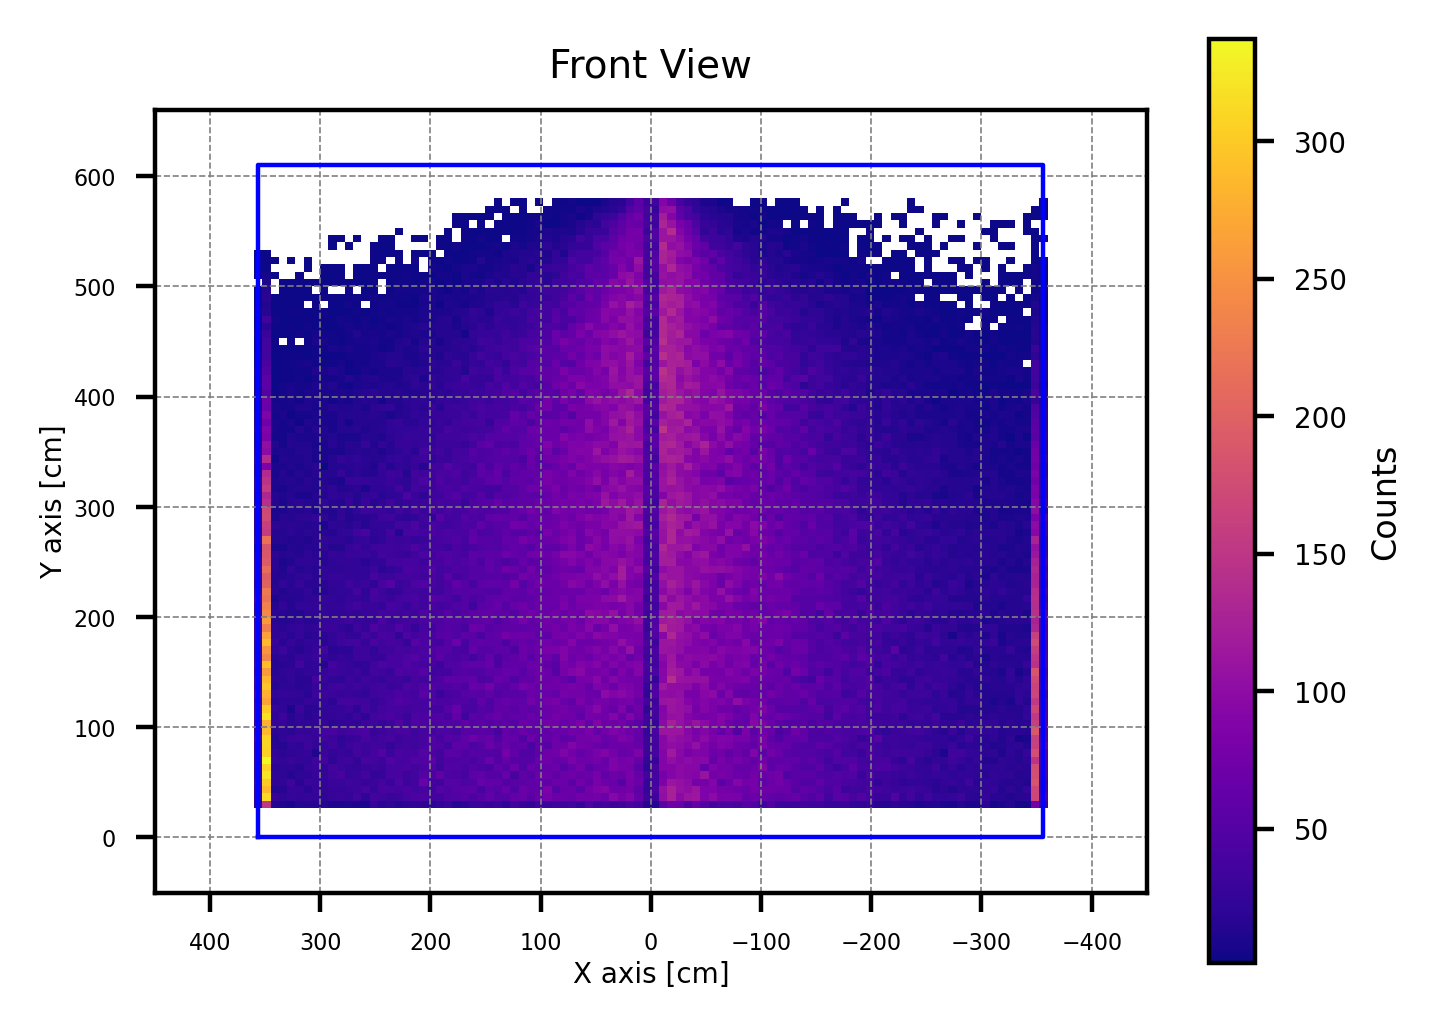

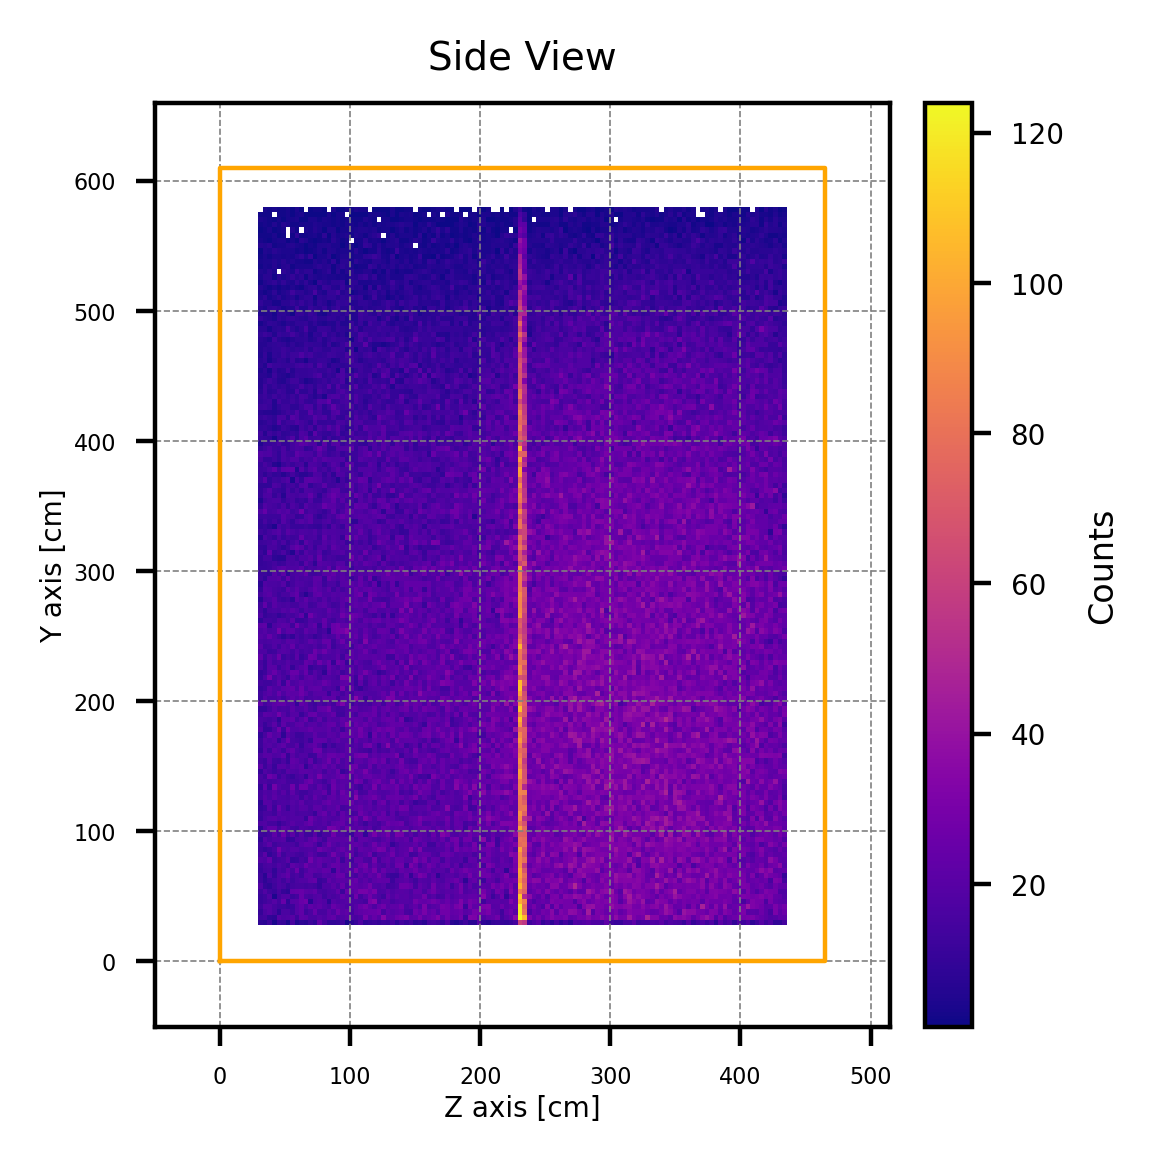


min(vals_MS_initial) 0.0
MS<0.01:  306798 / 326352 (94.01%)


<Figure size 1600x1200 with 0 Axes>

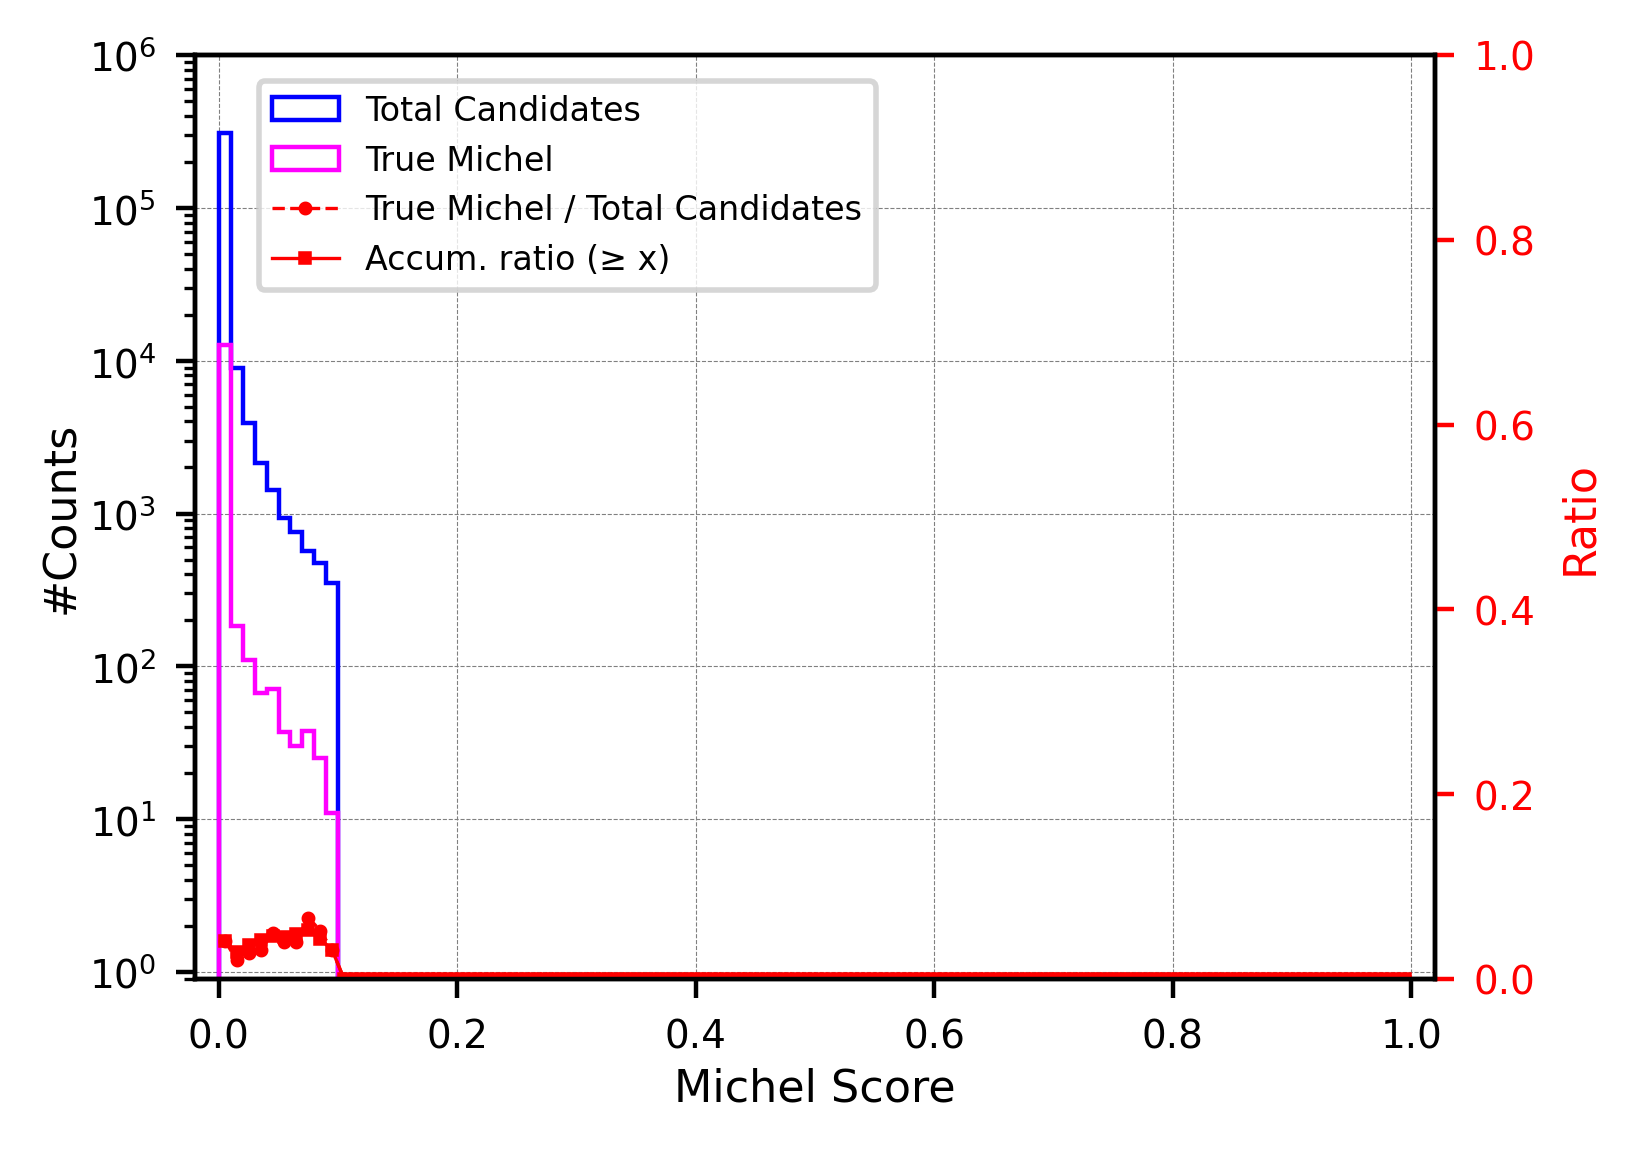

<Figure size 1600x1200 with 0 Axes>

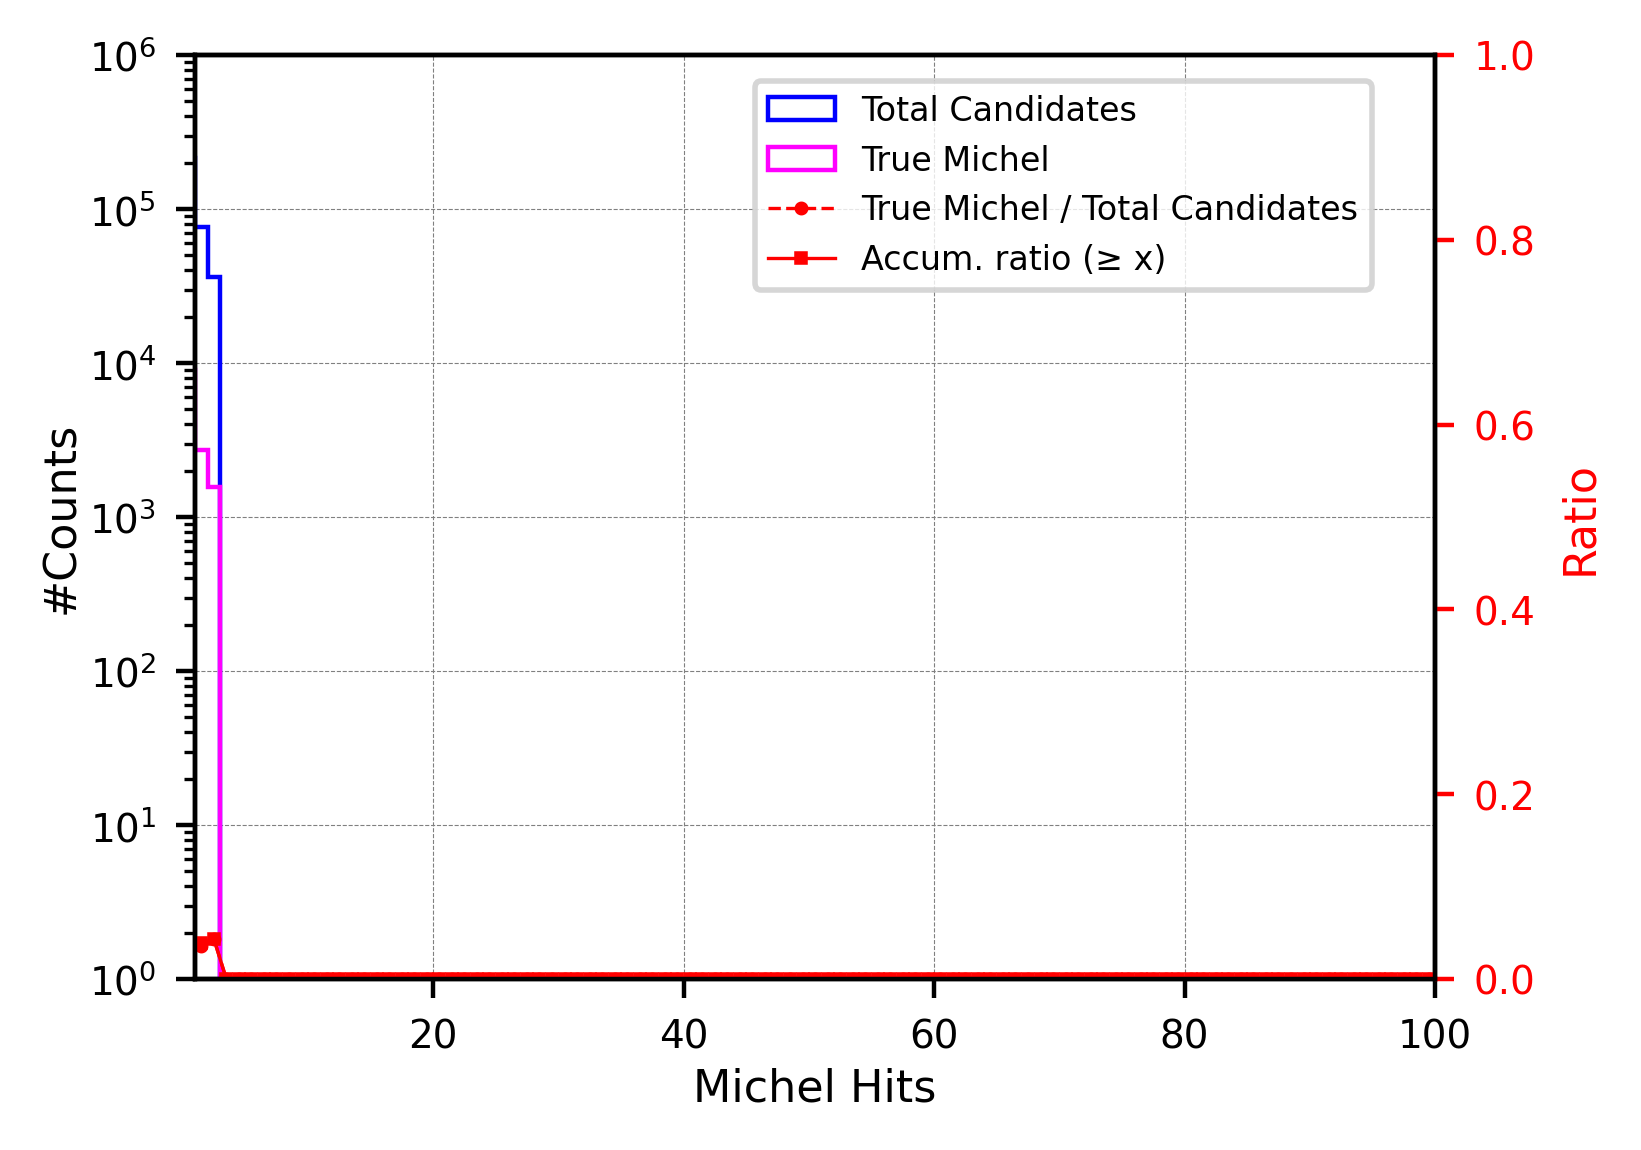

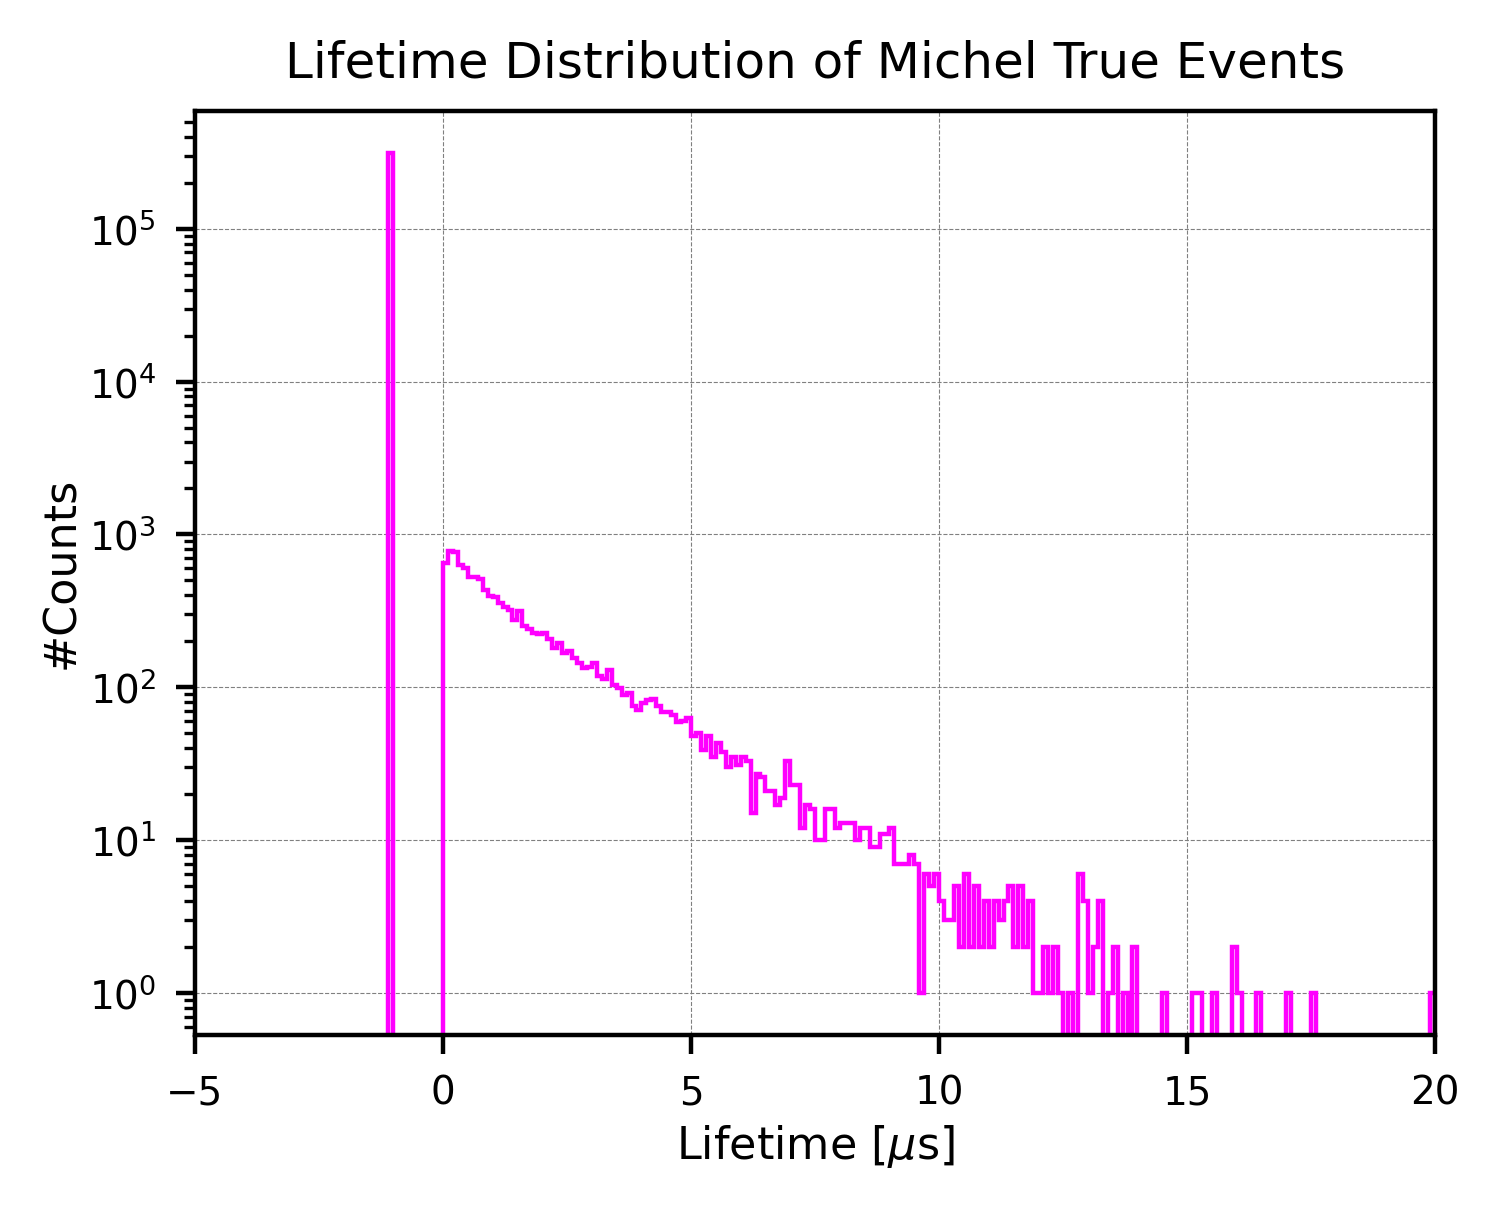

In [23]:



#Initial values:
vals_decayX_initial = [ev.decayX_initial for ev in Space_events_reco_bkg]
vals_decayY_initial = [ev.decayY_initial for ev in Space_events_reco_bkg]
vals_decayZ_initial = [ev.decayZ_initial for ev in Space_events_reco_bkg]
vals_MS_initial = [ev.MS_initial for ev in Space_events_reco_bkg]
vals_MH_initial = [ev.MH_initial for ev in Space_events_reco_bkg]
vals_lifetime_initial = [ev.lifetime_initial for ev in Space_events_reco_bkg]

vals_decayX_true = [ev.decayX_initial for ev in Space_events_true_bkg]
vals_MS_true = [ev.MS_initial for ev in Space_events_true_bkg]
vals_MH_true = [ev.MH_initial for ev in Space_events_true_bkg]




#Decay points distribution:==========================================
print("\nDecay points distribution: ")

decayX_initial = np.array(decayX_initial)
neg_X = np.sum(decayX_initial < 0)
pos_X = np.sum(decayX_initial >= 0)

num_negX = len([ev for ev in events_reco if ev.decayX_initial < 0])
num_posX = len([ev for ev in events_reco if ev.decayX_initial > 0])

print("# of X < 0 : ", num_negX, "({:.2f}%)".format(num_negX/len(events_reco)*100))
print("# of X >= 0: ", num_posX, "({:.2f}%)".format(num_posX/len(events_reco)*100))



# Plotting the histogram (X distribution)---------------
plt.figure(figsize=(4,3),dpi=400)

#APA planes---
plt.plot([-360, -360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')
plt.plot([360, 360], [0, 3000], color="blue", linewidth=0.8, linestyle='--')

#Define the range and bin width
bin_width = 10
range_min = -400
range_max = 400
bins = np.arange(range_min, range_max + bin_width, bin_width)


plt.hist(vals_decayX_initial, bins=bins, range=(range_min, range_max), edgecolor='black', 
         histtype='step', linewidth=0.8, label="Reconstructed events")
plt.hist(vals_decayX_true, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='bar', linewidth=0.8, label="True Michel events")


plt.xlim(-450, 450)
plt.xlabel(r'$x_1$ [cm]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
plt.gca().invert_xaxis()  # Flip x-axis
#plt.ylim(0.1, 30000)
#plt.yscale('log')
plt.title('Decay Points Distribution Along Drift Direction', fontsize=7)
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.legend(loc='upper center', bbox_to_anchor=(0.77, 0.95), fontsize=10, markerscale=6, ncol=1, prop={'size': 7})

plt.show()  






#Z-X plane ploting (Top View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux1 = [0, 465, 465, 0, 0] #y shoud be y---
aux2 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayX_initial, bins=(120, 120), range=[[zmin, zmax], [xmin, xmax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.3)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

plt.axis('scaled')
plt.ylim(-450, 450)#z---
plt.xlim(-50, 515)
plt.ylabel('X axis [cm]', labelpad=1, fontsize=5)
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.title('Top View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show()







#Y-X plane ploting (Front View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [0, 610, 610, 0, 0] #y shoud be y---
aux1 = [356, 356, -356, -356, 356]
plt.plot(aux1, aux2, color="blue", linewidth=0.8, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayX_initial, vals_decayY_initial, bins=(120, 120), range=[[xmin, xmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-450, 450)#z---
plt.ylim(-50, 660)
plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('X axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Front View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 




#Y-Z plane ploting (Side View)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

#auxiliary line, along y(geo) and x axis---
aux2 = [cageMinY, cageMaxY, cageMaxY, cageMinY, cageMinY] #y shoud be y---
aux1 = [cageMinZ, cageMinZ, cageMaxZ, cageMaxZ, cageMinZ]
plt.plot(aux1, aux2, color="orange", linewidth=0.8, linestyle='-')

# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(vals_decayZ_initial, vals_decayY_initial, bins=(200, 200), range=[[zmin, zmax], [ymin, ymax]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar(pad=-0.2)
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)


plt.axis('scaled')
plt.xlim(-50, 515)#z---
plt.ylim(-50, 660)
#plt.gca().invert_xaxis()  # Flip x-axis
plt.xlabel('Z axis [cm]', labelpad=1, fontsize=5)
plt.ylabel('Y axis [cm]', labelpad=1, fontsize=5)
plt.title('Side View', fontsize=7)
plt.tick_params(labelsize=4)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.3, zorder=0)
plt.show() 








#Michel score distribution (Original)----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

print("\n==========================")
print("min(vals_MS_initial)", min(vals_MS_initial))
count = sum(1 for x in vals_MS_initial if x < 0.01)
print("MS<0.01: ", count, "/", len(vals_MS_initial),   "({:.2f}%)".format(count/len(vals_MS_initial)*100))



# Define the range and bin width
bin_width = 0.01
range_min = 0.0 #====================Remember to recover back---
range_max = 1.00
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MS_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MS_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([0.5, 0.5], [0, 100000], color="green", linewidth=1.2, linestyle='--')

# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(-0.02, 1.02) #(-0.02, 1.02)
ax1.set_ylim(0.9, 1000000)
plt.yscale('log')
ax1.set_xlabel('Michel Score', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")


# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')


ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.set_ylim(0, 1.0)
ax2.tick_params(axis='y', labelsize=7, colors='red')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.3, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})


plt.show()








#Michel hits distribution (Original)-----------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Define the range and bin width
bin_width = 1
range_min = 0
range_max = 100
bins = np.arange(range_min, range_max + bin_width, bin_width)

# Compute histograms
hist_total, _ = np.histogram(vals_MH_initial, bins=bins, range=(range_min, range_max))
hist_true, _ = np.histogram(vals_MH_true, bins=bins, range=(range_min, range_max))

# Compute bin centers (midpoints of bins)
bin_centers = bins[:-1] + bin_width / 2

fig, ax1 = plt.subplots(figsize=(4,3), dpi=400)


#plt.plot([8, 8], [0, 300000], color="green", linewidth=1.2, linestyle='--')


# Primary y-axis (Counts)
ax1.hist(bin_centers, bins=bins, weights=hist_total, edgecolor='blue', histtype='step', linewidth=0.8, label="Total Candidates")
ax1.hist(bin_centers, bins=bins, weights=hist_true, edgecolor='magenta', histtype='step', linewidth=0.8, label="True Michel")

ax1.set_xlim(1, 100)
ax1.set_ylim(1, 1000000)
ax1.set_xlabel('Michel Hits', labelpad=2, fontsize=8)
ax1.set_ylabel('#Counts', labelpad=1, fontsize=8)
plt.yscale('log')
ax1.tick_params(labelsize=7)
ax1.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
#plt.legend(loc='upper center', bbox_to_anchor=(0.3, 0.99), fontsize=9, markerscale=5, ncol=1, prop={'size': 6})

# Secondary y-axis (Ratio)
ax2 = ax1.twinx()
ax2.set_ylim(0, 1.0)
ratio = np.divide(hist_true, hist_total, out=np.zeros_like(hist_true, dtype=float), where=hist_total!=0)  # Avoid division by zero
ax2.plot(bin_centers, ratio, color='red', marker='o', markersize=1.5, linestyle='--', linewidth=0.6, label="True Michel / Total Candidates")



# --- Accumulated (>= x) ratio ---
# Cumulative sums from the right (>= x)
cum_total = np.cumsum(hist_total[::-1])[::-1]
cum_true  = np.cumsum(hist_true[::-1])[::-1]
acc_ratio = np.divide(cum_true, cum_total,
                      out=np.zeros_like(cum_true, dtype=float),
                      where=cum_total != 0)

# Add the accumulated ratio curve on the secondary y-axis
ax2.plot(bin_centers, acc_ratio, color='red', marker='s', markersize=1.5,
         linestyle='-', linewidth=0.6, label='Accum. ratio (≥ x)')



ax2.set_ylabel('Ratio', fontsize=8, color='red')
ax2.tick_params(axis='y', labelsize=7, colors='red')


# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.7, 0.99),
           fontsize=9, ncol=1, prop={'size': 6})

plt.show() 








#True Lifetime distribution==================================================
plt.figure(figsize=(4,3),dpi=400)
bin_width = 0.1
range_min = -20
range_max = 20
bins = np.arange(range_min, range_max + bin_width, bin_width)

plt.hist(vals_lifetime_initial, bins=bins, range=(range_min, range_max), edgecolor='magenta', 
         histtype='step', linewidth=0.8)

plt.xlim(-5, 20)
plt.xlabel('Lifetime [$\mu$s]', labelpad=2, fontsize=8)
plt.ylabel('#Counts', labelpad=1, fontsize=8)
#plt.ylim(0.1, 6000)
plt.yscale('log')
plt.tick_params(labelsize=7)#set the size of ticks---
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)
plt.title('Lifetime Distribution of Michel True Events', fontsize=9)
plt.show()







